# **Проект по созданию модели машинного обучения для предсказания цены на велопрокат города Сочи**

## Описание задачи
Компания **BikeSochi**, оператор городского велопроката в Сочи, обратилась за помощью в улучшении системы прогнозирования почасового спроса на велосипеды.

До этого аналитики компании использовали простую линейную регрессию — одну из самых базовых моделей машинного обучения.

Однако её прогнозы часто ошибались:



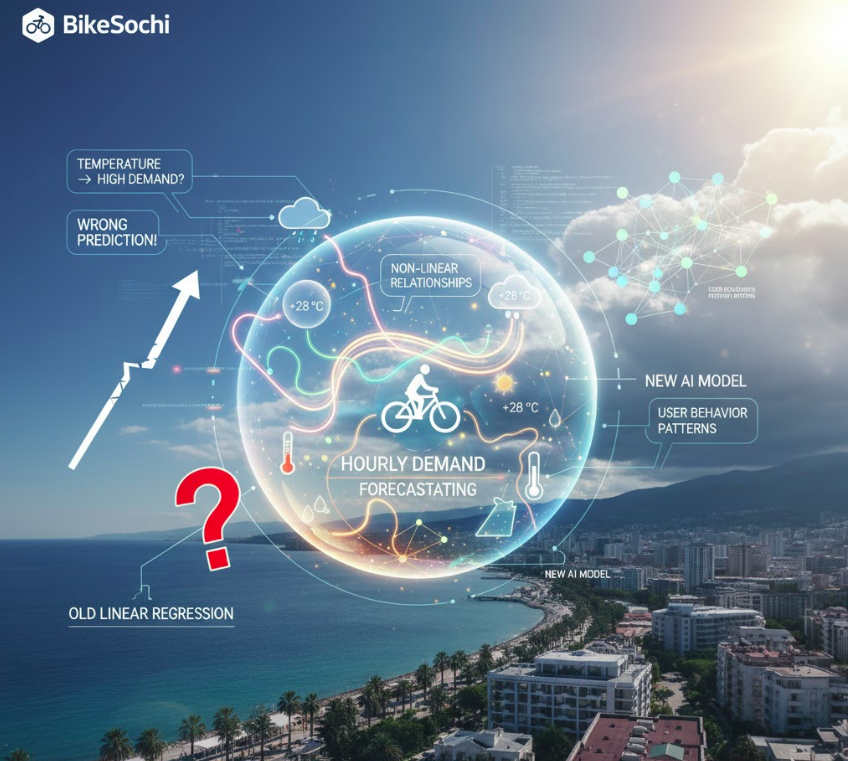

> «Модель видела, что температура выросла — и сразу предсказывала высокий спрос.
Но не понимала, что +28 °C под палящим солнцем и +28 °C после дождя — это две совсем разные ситуации.»

Погода в Сочи меняется быстро, и влияние факторов — нелинейное: температура, влажность, солнечная радиация, осадки влияют на поведение людей не по простым прямым зависимостям.



Поведение пользователей на черноморском побережье действительно сильно зависит от сочетания разных факторов: температуры, солнечной активности, влажности, осадков и времени суток. Чтобы уловить эти зависимости, линейных моделей уже недостаточно. В этой ситуации должны помочь гибкие алгоритмы, способные понимать контекст и взаимодействие признаков. 
Компания уверена: ключ к стабильной работе системы — точный прогноз почасового спроса, учитывающий реальные погодные и сезонные факторы. 

**Цель:** Разработать модель, которая будет предсказывать, сколько велосипедов потребуется в каждый конкретный час, исходя из погодных и календарных условий.

**Для компании важно:**

- Повысить точность прогнозов.

- Оптимизировать логистику распределения велосипедов.

- Улучшить клиентский опыт, избегая простоев и дефицита.

**Основные задачи проекта:**

- изучить качество baseline-модели на основе линейной регрессии;
- провести исследовательский анализ данных;
- подготовить данные для обучения моделей;
- обучить две нелинейные модели:
  - KNeighborsRegressor;
  - DecisionTreeRegressor;
- подобрать оптимальные гиперпараметры с помощью Optuna;
- сравнить модели по метрикам RMSE, MAE и R²;
- выбрать лучшую модель и проверить её качество на тестовой выборке;
- проанализировать важность признаков и сделать выводы для бизнеса.


**Данные:**

- `baseline_linear_regression_pipeline.pkl` - готовый baseline-пайплайн с линейной регрессией;
- `ds_s14_train_data.csv` - данные для обучения и валидации моделей;
- `ds_s14_test_data.csv` - тестовая выборка для финальной проверки качества.

**Целевая переменная:**

- `Rented Bike Count` - количество арендованных велосипедов за конкретный час.

**Описание признаков:**

- `Temperature` - температура воздуха (°C);
- `Humidity` - влажность воздуха (%);
- `Windspeed` - скорость ветра (м/с);
- `Visibility` - видимость;
- `Dew Point Temperature` - температура точки росы (°C);
- `Solar Radiation` - солнечная радиация;
- `Rainfall` - количество осадков;
- `Snowfall` - количество снега;
- `Seasons` - время года;
- `Holiday` - праздничный или выходной день;
- `Functioning Day` - работала ли система проката;
- признаки временных периодов:
  - `Night`
  - `Morning`
  - `Evening`
  - `Late Evening`

Если все временные признаки имеют значение `False`, запись относится к периоду `Daytime`.

Каждая строка датасета описывает погодные и календарные условия в определённый час и соответствующий спрос на аренду велосипедов.

## Базовая модель

Загружаем все енобходимые версии библиотек:

In [1]:
! pip install phik -q
! pip install category-encoders -q
! pip uninstall -y numpy pandas scipy scikit-learn matplotlib seaborn pyarrow phik -q 
! pip install -q \
numpy==1.26.4 \
pandas==2.2.3 \
scipy==1.13.1 \
scikit-learn==1.6.1 \
matplotlib==3.9.0 \
seaborn==0.13.2 \
pyarrow==18.1.0 \
phik==0.12.4 \
joblib==1.4.2 \
numba==0.60.0 \
optuna
  

In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from phik import phik_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score, KFold
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Для оптимизации гиперпараметров 
import optuna

RANDOM_SEED = 42

По условию нам дана модель линейной регрессии и данные, с помощью которых мы сможем проверить её качество.

In [3]:
#Загружаем линейную модель заказчика
model_lin = joblib.load('baseline_linear_regression_pipeline.pkl')

In [4]:
# Загрузка данных
train_df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_train_data.csv')
test_df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_test_data.csv')

print(f"Размер обучающей выборки: {train_df.shape}")
print(f"Размер тестовой выборки: {test_df.shape}")

Размер обучающей выборки: (7008, 16)
Размер тестовой выборки: (1752, 16)


In [5]:
# Разделяем данные
X_train = train_df.drop('Rented Bike Count', axis=1)
y_train = train_df['Rented Bike Count']
X_test = test_df.drop('Rented Bike Count', axis=1)
y_test = test_df['Rented Bike Count']

In [6]:
X_train.columns

Index(['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
       'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day',
       'Time_Period_Evening', 'Time_Period_Late Evening',
       'Time_Period_Morning', 'Time_Period_Night'],
      dtype='object')

In [7]:
# Делаем предсказания
train_pred = model_lin.predict(X_train)
test_pred = model_lin.predict(X_test)

# Считаем метрики
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

# Выводим результаты
print("=== МЕТРИКИ БАЗОВОЙ МОДЕЛИ ===")
print(f"RMSE (обучение): {train_rmse:.2f}")
print(f"RMSE (тест): {test_rmse:.2f}")
print(f"MAE (обучение): {train_mae:.2f}")
print(f"MAE (тест): {test_mae:.2f}")
print(f"R² (обучение): {train_r2:.3f}")
print(f"R² (тест): {test_r2:.3f}")

=== МЕТРИКИ БАЗОВОЙ МОДЕЛИ ===
RMSE (обучение): 412.53
RMSE (тест): 411.56
MAE (обучение): 309.08
MAE (тест): 312.60
R² (обучение): 0.593
R² (тест): 0.586


In [8]:
model_lin

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)']),
                                                 ('str_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day']),
                                                 ('ohe_pass', 'passthrough',
                                                  ['Time_Period_Evening',
                                                   'Time_Period_Late Evening',
                                                   'Time_Period_Morning',
                                                   'Time_Period_Night'])])),
                ('regressor', LinearRegression())])

**Вывод по линейной модели**

Линейная модель заказчика, несмотря на не самый маленький R, демонстрирует весьма скудные метрики качества. Что подтверждает гипотезу о меньшей точности модели на данных с нелинейной зависимостью. 

## Исследовательский анализ данных

### Информация о данных

In [9]:
display(train_df.head())
display(train_df.info())

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

None

In [10]:
#Фмксируем размер исходного датасета
temp = len(train_df)

**Общая характеристика**

- Объём: 7008 строк — вполне достаточный размер для обучения ML‑моделей (в том числе пайплайнов с кросс‑валидацией).

- Число признаков: 15 признаков для моделирования (целевая переменная Rented Bike Count отдельно).

- Типы данных: смешаны числовые (float64, int64), категориальные (object) и бинарные (bool). Это как раз тот случай, где удобно использовать ColumnTransformer

In [11]:
#Выведем общую статистику по числовым признакам
train_df.describe()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,7008.000000,6758.000000,6798.000000,6749.000000,7008.000000,6798.000000,6746.000000,6745.000000,7008.000000
mean,12.812914,58.200503,1.725228,1435.156764,4.021490,0.569885,0.146902,0.074752,705.606022
std,11.924688,20.340317,1.042956,607.291049,13.033377,0.866142,1.164118,0.438189,646.311790
min,-17.500000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000
25%,3.300000,42.000000,0.900000,936.000000,-4.700000,0.000000,0.000000,0.000000,190.750000
50%,13.500000,57.000000,1.500000,1691.000000,5.000000,0.010000,0.000000,0.000000,504.500000
75%,22.400000,74.000000,2.300000,2000.000000,14.800000,0.940000,0.000000,0.000000,1070.000000
max,39.400000,98.000000,7.400000,2000.000000,26.800000,3.520000,35.000000,8.800000,3556.000000


### Анализ пропусков

In [12]:
#Посчитаем количество пропущенных значений
train_df.isnull().sum()

Temperature                   0
Humidity(%)                 250
Wind speed (m/s)            210
Visibility (10m)            259
Dew point temperature         0
Solar Radiation (MJ/m2)     210
Rainfall(mm)                262
Snowfall (cm)               263
Seasons                       0
Holiday                       0
Functioning Day               0
Time_Period_Evening           0
Time_Period_Late Evening      0
Time_Period_Morning           0
Time_Period_Night             0
Rented Bike Count             0
dtype: int64

**Краткий вывод**

В датасете нет пропусков в целевой переменной и ключевых категориальных признаках (Seasons, Holiday, Functioning Day, временные периоды и т.д.) — это хорошо для чистоты эксперимента и интерпретации. При этом во всех основных погодных числовых колонках есть пропуски (210–263), причём их количество сопоставимо между признаками — скорее всего, это систематический сбой сбора данных , а не случайные единичные пропуски.

Погодные числовые признаки — пропуски есть везде

`Humidity(%)` — 250  
`Visibility (10m)` — 259  
`Rainfall(mm)` — 262  
`Snowfall (cm)` — 263  
`Wind speed (m/s)` — 210  
`Solar Radiation (MJ/m2)` — 210

### Обработка дубликатов

In [13]:
# Полные дубликаты
full_dup_mask = train_df.duplicated(keep=False)
full_duplicates = train_df[full_dup_mask]
print("Количество полных дубликатов:", full_duplicates.shape[0])

# Неполные дубликаты по ключевым колонкам
key_cols = ['Temperature', 'Humidity(%)', 'Wind speed (m/s)',
            'Dew point temperature', 'Solar Radiation (MJ/m2)']

partial_dup_mask = train_df.duplicated(subset=key_cols, keep='first')
partial_duplicates = train_df[partial_dup_mask]
print("Количество неполных дубликатов по ключевым колонкам:", partial_duplicates.shape[0])

Количество полных дубликатов: 0
Количество неполных дубликатов по ключевым колонкам: 11


In [14]:
# drop_duplicates по ключевым колонкам, оставляем первую строку из группы
train_df = train_df.drop_duplicates(subset=key_cols)

print("Было строк:", temp)
print("Стало строк:", train_df.shape[0])
print("Удалено неполных дубликатов:", temp - train_df.shape[0])


Было строк: 7008
Стало строк: 6997
Удалено неполных дубликатов: 11


### Исследования целевой переменной

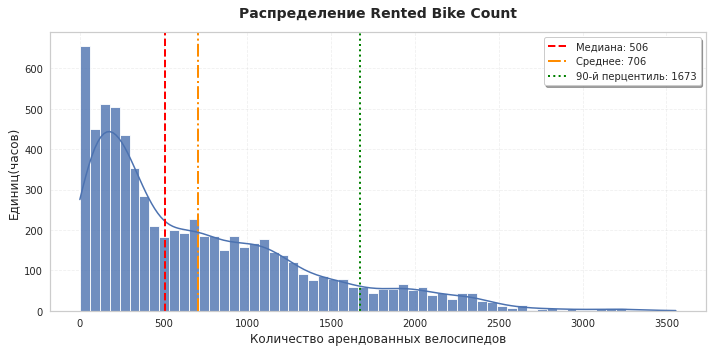

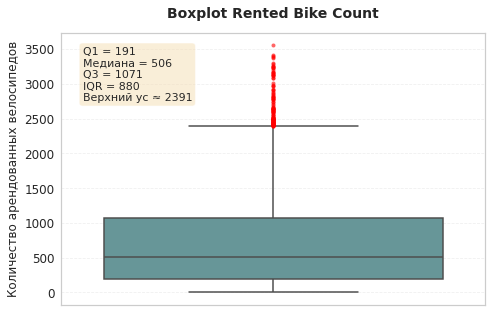

In [15]:
sns.set_style("whitegrid")
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["font.size"] = 12

fig, ax = plt.subplots(figsize=(10, 5))

# Гистограмма и KDE
sns.histplot(train_df['Rented Bike Count'], bins=60, kde=True, ax=ax, color="#4c72b0", alpha=0.8)

# Добавим вертикальные линии для ключевых статистик
median_val = train_df['Rented Bike Count'].median()
mean_val = train_df['Rented Bike Count'].mean()
p90_val = np.percentile(train_df['Rented Bike Count'], 90)

ax.axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Медиана: {median_val:.0f}')
ax.axvline(mean_val, color='darkorange', linestyle='-.', linewidth=2, label=f'Среднее: {mean_val:.0f}')
ax.axvline(p90_val, color='green', linestyle=':', linewidth=2, label=f'90-й перцентиль: {p90_val:.0f}')

ax.set_title('Распределение Rented Bike Count', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Количество арендованных велосипедов', fontsize=12)
ax.set_ylabel('Единиц(часов)', fontsize=12)

ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


sns.set_style("whitegrid")
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["font.size"] = 12

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.boxplot(y=train_df['Rented Bike Count'], ax=ax, color="#5f9ea0", linewidth=1.5, flierprops=dict(marker='o', markerfacecolor='red', markersize=4, markeredgecolor='none', alpha=0.6))

ax.set_title('Boxplot Rented Bike Count', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Количество арендованных велосипедов', fontsize=12)
ax.set_xlabel('')  # убираем пустую подпись оси X

# Подпишем ключевые значения на boxplot
q1 = train_df['Rented Bike Count'].quantile(0.25)
q3 = train_df['Rented Bike Count'].quantile(0.75)
iqr = q3 - q1
upper_whisker = q3 + 1.5 * iqr

text_str = (f'Q1 = {q1:.0f}\n'
            f'Медиана = {train_df["Rented Bike Count"].median():.0f}\n'
            f'Q3 = {q3:.0f}\n'
            f'IQR = {iqr:.0f}\n'
            f'Верхний ус ≈ {upper_whisker:.0f}')

ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

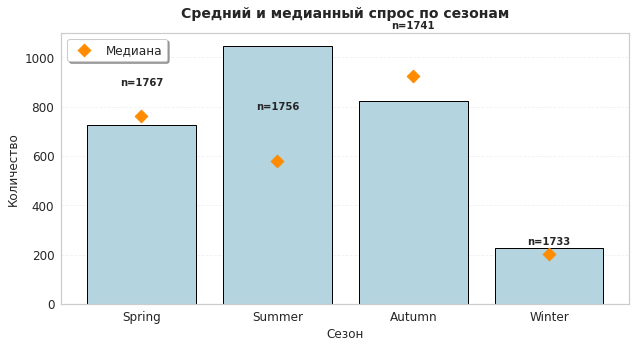

Seasons   mean  median   std  count
 Spring  725.6   579.0 619.7   1756
 Summer 1047.5   925.0 690.1   1741
 Autumn  821.5   764.0 654.2   1767
 Winter  226.5   204.0 150.9   1733


In [16]:
sns.set_style("whitegrid")
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["font.size"] = 12

# Считаем статистику
seasonal_stats = train_df.groupby('Seasons')['Rented Bike Count'].agg(['mean', 'median', 'std', 'count']).reset_index()

# Фиксируем порядок сезонов
order = ['Spring', 'Summer', 'Autumn', 'Winter']
seasonal_stats['Seasons'] = pd.Categorical(seasonal_stats['Seasons'], categories=order, ordered=True)
seasonal_stats = seasonal_stats.sort_values('Seasons')

fig, ax = plt.subplots(figsize=(9, 5))

# Барплот по среднему
bars = sns.barplot(data=seasonal_stats, x='Seasons', y='mean', ax=ax, color="lightblue", edgecolor='black', linewidth=1)

# Добавим медиану как точки
ax.scatter(seasonal_stats.index, seasonal_stats['median'], color='darkorange', s=80, zorder=5, label='Медиана', marker='D')

# Подпишем количество наблюдений над каждым столбцом
for i, row in seasonal_stats.iterrows():
    ax.text(i, row['mean'] + row['std']*0.1, f"n={int(row['count'])}", ha='center', fontsize=10, fontweight='bold')

ax.set_title('Средний и медианный спрос по сезонам', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Сезон', fontsize=12)
ax.set_ylabel('Количество', fontsize=12)

ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Красиво выводим таблицу статистики
print(seasonal_stats.to_string(index=False, float_format=lambda x: f'{x:.1f}' if isinstance(x, float) else str(x)))

**Ключевые закономерности**

- Максимум спроса — летом (mean ≈ 1046, median ≈ 923). Это самый «горячий» сезон: и средний, и медианный спрос здесь самые высокие.

- Весна: mean 725, median 578 — среднее заметно выше медианы, значит, в отдельные дни бывают сильные всплески спроса.

- Осень: mean 821, median 764 — распределение более сбалансированное, всплески менее выражены.

- Зима — резкий провал (mean 226, median 204). Спрос примерно в 3–4 раза ниже, чем летом, и гораздо стабильнее (низкий разброс: std 151 против 690 летом).

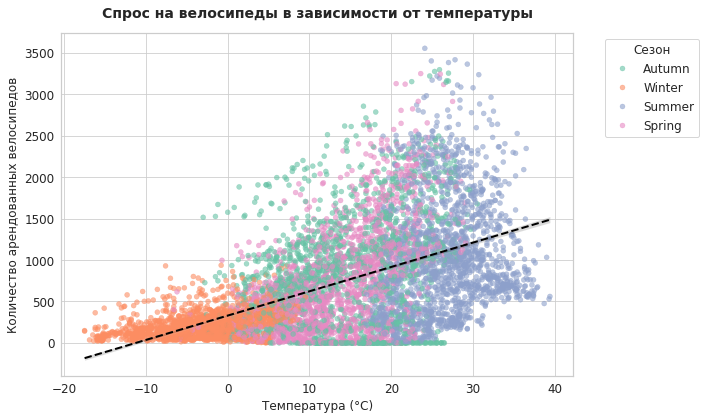

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=train_df,
    x='Temperature',
    y='Rented Bike Count',
    hue='Seasons',
    palette='Set2',
    s=25,
    alpha=0.6,
    edgecolor=None
)

# Добавим сглаженную линию тренда (по всем данным)
sns.regplot(
    data=train_df,
    x='Temperature',
    y='Rented Bike Count',
    scatter=False,
    color='black',
    line_kws={'linewidth': 2, 'linestyle': '--'}
)

plt.title('Спрос на велосипеды в зависимости от температуры', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Температура (°C)', fontsize=12)
plt.ylabel('Количество арендованных велосипедов', fontsize=12)
plt.legend(title='Сезон', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

По графику можем видеть линеную зависимость: чем больше температура тем больше спрос.

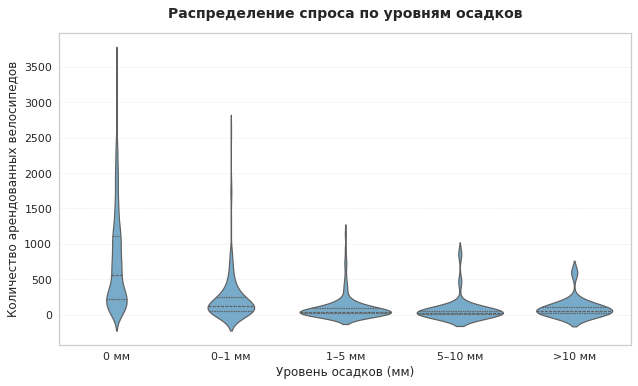

In [18]:
sns.set_style("whitegrid")
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["font.size"] = 11

# Биннинг осадков
train_df['Rainfall_bin'] = pd.cut(
    train_df['Rainfall(mm)'],
    bins=[-1, 0, 1, 5, 10, train_df['Rainfall(mm)'].max()],
    labels=['0 мм', '0–1 мм', '1–5 мм', '5–10 мм', '>10 мм']
)

plt.figure(figsize=(9, 5.5))
sns.violinplot(
    data=train_df,
    x='Rainfall_bin',
    y='Rented Bike Count',
    inner='quartile',          # показываем квартили
    linewidth=1.2,            # чёткие границы
    color='#6baed6'           # вместо palette — один цвет (или можно использовать saturation и т.п.)
)

plt.title('Распределение спроса по уровням осадков', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Уровень осадков (мм)', fontsize=12)
plt.ylabel('Количество арендованных велосипедов', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

train_df.drop(columns=['Rainfall_bin'], inplace=True, errors='ignore')

Очевидно, что количество имеет обратную зависимость, в дождливую погоду спрос минимальный

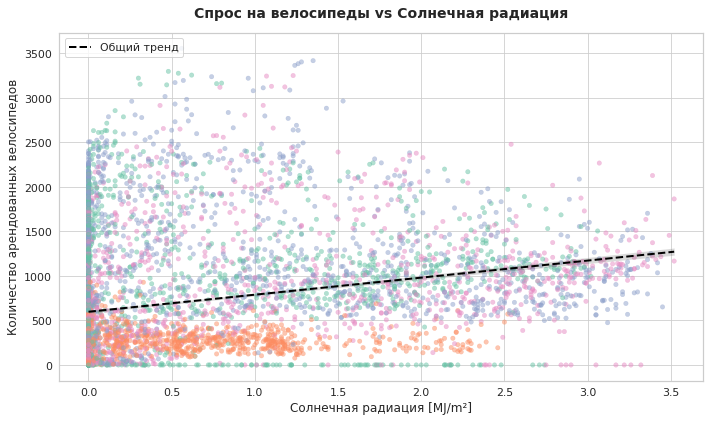

In [19]:
sns.set_style("whitegrid")
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["font.size"] = 11

plt.figure(figsize=(10, 6))

# Scatter по сезонам
sns.scatterplot(
    data=train_df,
    x='Solar Radiation (MJ/m2)',
    y='Rented Bike Count',
    hue='Seasons',
    palette='Set2',
    s=20,
    alpha=0.5,
    edgecolor=None,
    legend=False
)

# Общий тренд (без точек)
sns.regplot(
    data=train_df,
    x='Solar Radiation (MJ/m2)',
    y='Rented Bike Count',
    scatter=False,
    color='black',
    line_kws={'linewidth': 2, 'linestyle': '--'}
)

plt.title('Спрос на велосипеды vs Солнечная радиация', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Солнечная радиация [MJ/m²]', fontsize=12)
plt.ylabel('Количество арендованных велосипедов', fontsize=12)

# Легенда только по сезонам (через handles из scatter)
handles, labels = plt.gca().get_legend_handles_labels()
if len(handles) > 0:
    plt.legend(handles, labels, title='Сезон', bbox_to_anchor=(1.05, 1), loc='upper left')
else:
    # fallback: просто чёрная линия
    from matplotlib.lines import Line2D
    custom_lines = [Line2D([0], [0], color='black', lw=2, linestyle='--')]
    plt.legend(custom_lines, ['Общий тренд'], loc='upper left')

plt.tight_layout()
plt.show()

Здесь чёткую зависимость проследить сложно, можно лишь сделать вывод, что при умеренной солнечной активности, спрос выше, нежели в очень жаркие и солнечные дни

### Анализ признаков

In [20]:
# Числовые признаки (для импутера + скейлера)
num_features = [
    'Temperature',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Dew point temperature',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)'
]

# Категориальные признаки (для OneHotEncoder)
cat_features = [
    'Seasons',
    'Holiday',
    'Functioning Day'
]

# Бинарные признаки
bin_features = [
    'Time_Period_Evening',
    'Time_Period_Late Evening',
    'Time_Period_Morning',
    'Time_Period_Night'
]


=== АНАЛИЗ ПРИЗНАКА: Temperature ===
Среднее: 12.8156
Медиана: 13.6000
Стандартное отклонение: 11.9265
Минимум: -17.5000
Максимум: 39.4000
Пропуски: 0
Выбросы (по IQR): 0


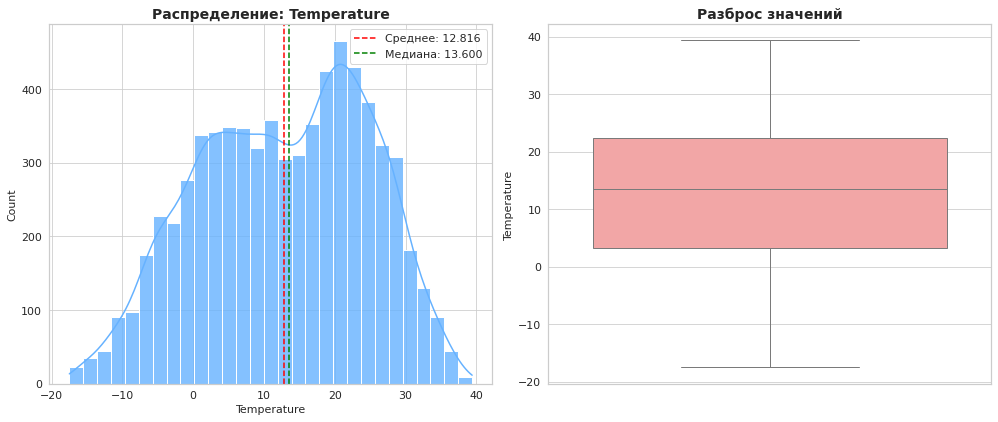


=== АНАЛИЗ ПРИЗНАКА: Humidity(%) ===
Среднее: 58.1773
Медиана: 57.0000
Стандартное отклонение: 20.3423
Минимум: 0.0000
Максимум: 98.0000
Пропуски: 250
Выбросы (по IQR): 0


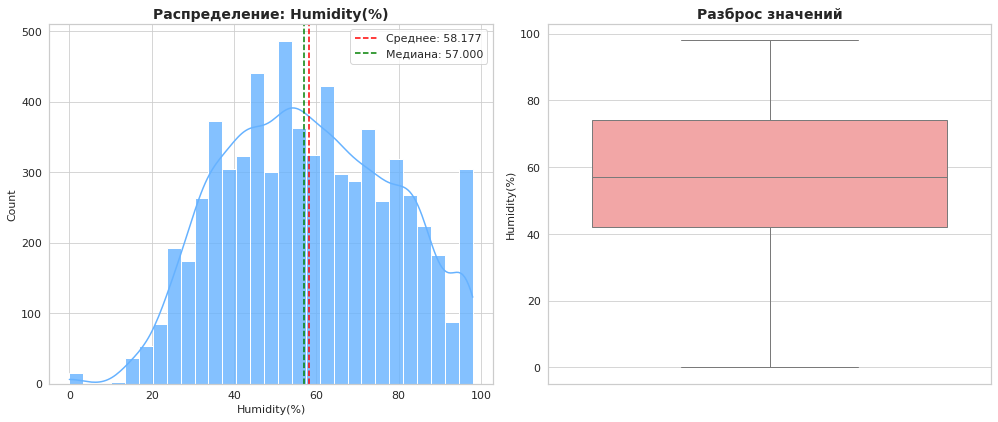


=== АНАЛИЗ ПРИЗНАКА: Wind speed (m/s) ===
Среднее: 1.7267
Медиана: 1.5000
Стандартное отклонение: 1.0430
Минимум: 0.0000
Максимум: 7.4000
Пропуски: 210
Выбросы (по IQR): 127


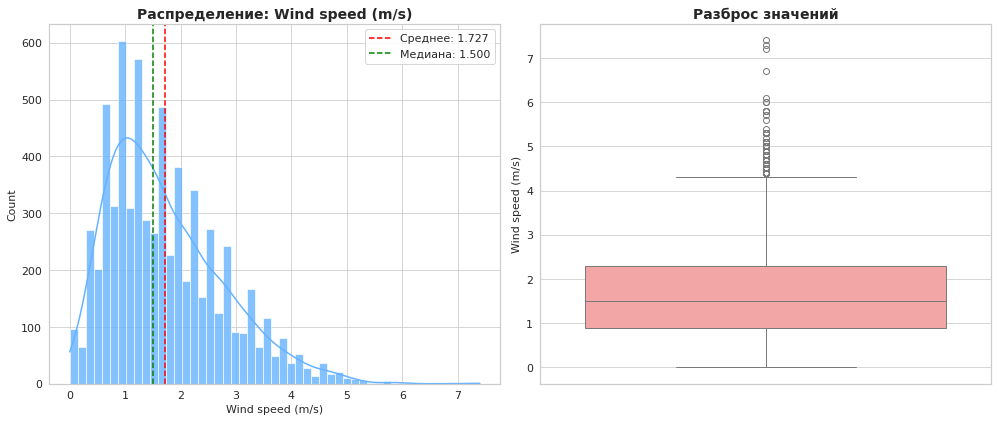


=== АНАЛИЗ ПРИЗНАКА: Visibility (10m) ===
Среднее: 1435.9191
Медиана: 1693.5000
Стандартное отклонение: 607.0001
Минимум: 27.0000
Максимум: 2000.0000
Пропуски: 259
Выбросы (по IQR): 0


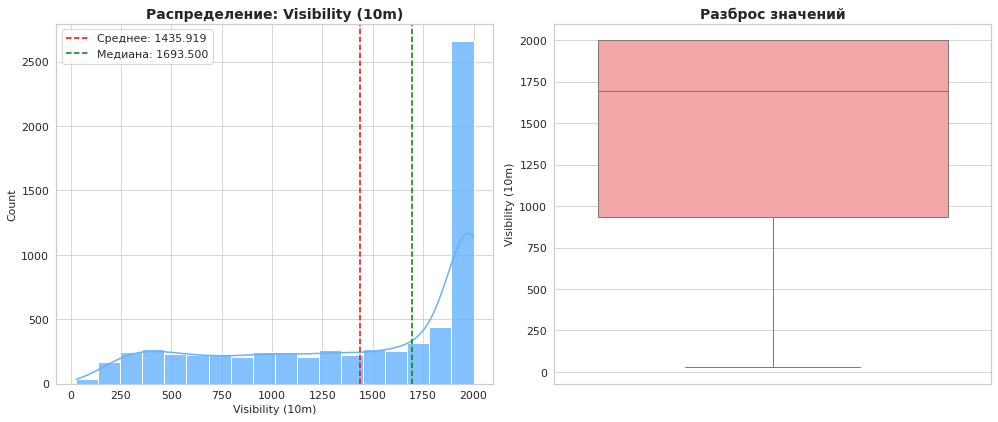


=== АНАЛИЗ ПРИЗНАКА: Dew point temperature ===
Среднее: 4.0180
Медиана: 5.0000
Стандартное отклонение: 13.0349
Минимум: -30.6000
Максимум: 26.8000
Пропуски: 0
Выбросы (по IQR): 0


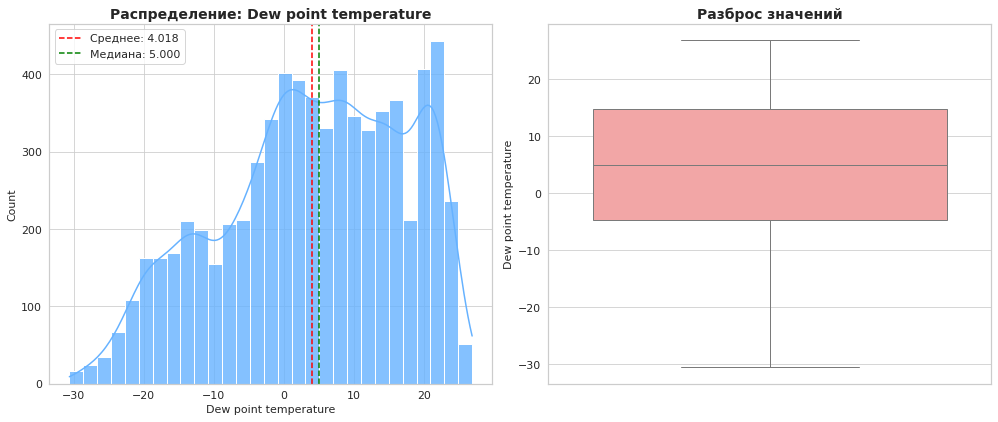


=== АНАЛИЗ ПРИЗНАКА: Solar Radiation (MJ/m2) ===
Среднее: 0.5708
Медиана: 0.0100
Стандартное отклонение: 0.8665
Минимум: 0.0000
Максимум: 3.5200
Пропуски: 210
Выбросы (по IQR): 473


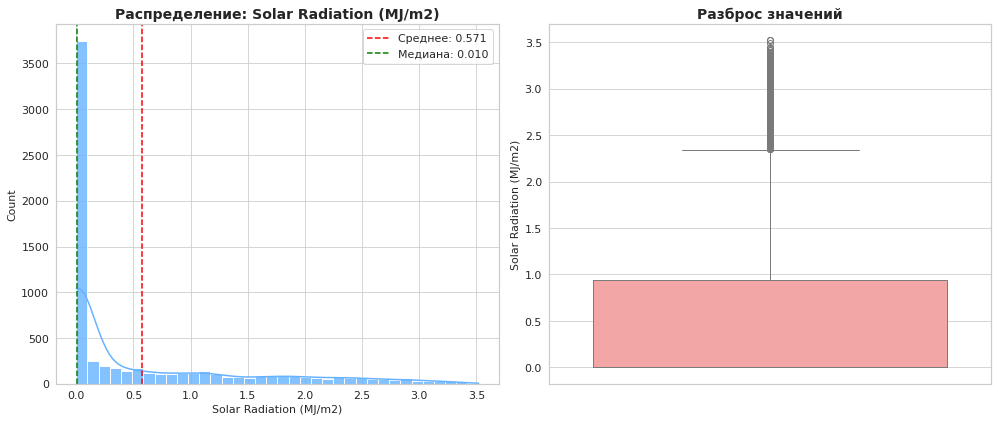


=== АНАЛИЗ ПРИЗНАКА: Rainfall(mm) ===
Среднее: 0.1463
Медиана: 0.0000
Стандартное отклонение: 1.1632
Минимум: 0.0000
Максимум: 35.0000
Пропуски: 262
Выбросы (по IQR): 384


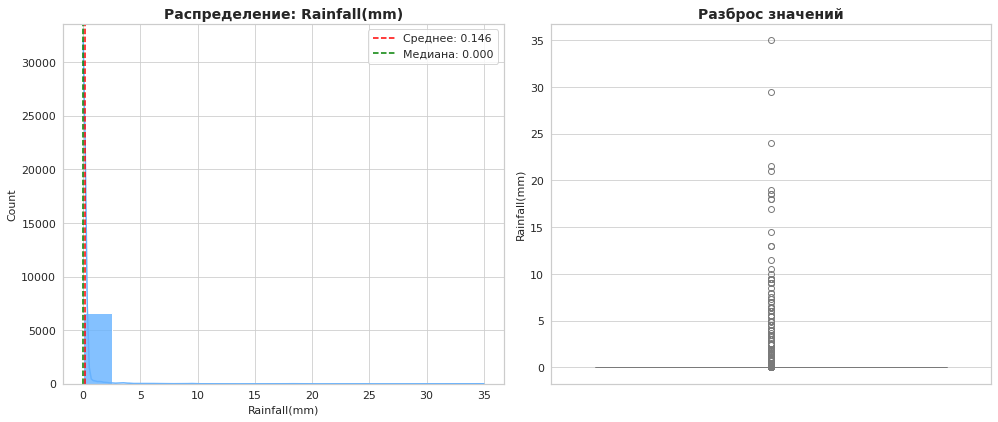


=== АНАЛИЗ ПРИЗНАКА: Snowfall (cm) ===
Среднее: 0.0748
Медиана: 0.0000
Стандартное отклонение: 0.4385
Минимум: 0.0000
Максимум: 8.8000
Пропуски: 263
Выбросы (по IQR): 341


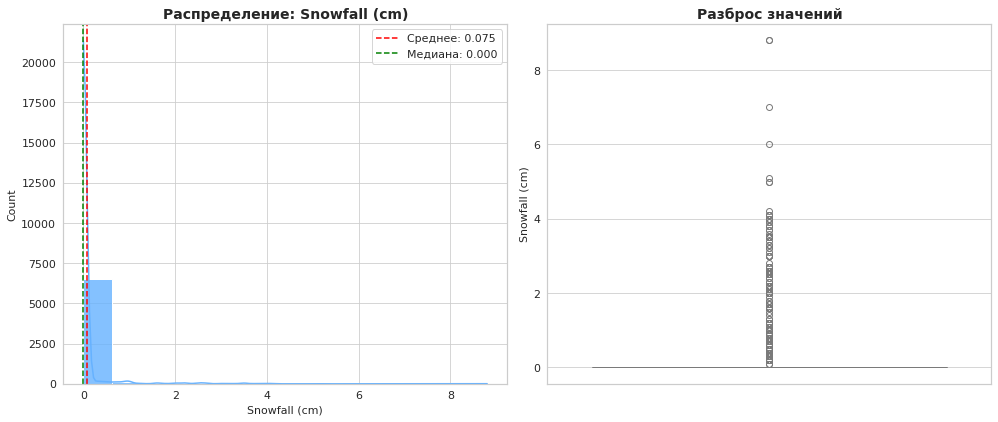

In [21]:
def analyze_and_plot_feature(feature_name, data):
    """Анализ и визуализация признака с выводом статистики"""
    print(f"\n=== АНАЛИЗ ПРИЗНАКА: {feature_name} ===")
    print(f"Среднее: {data[feature_name].mean():.4f}")
    print(f"Медиана: {data[feature_name].median():.4f}")
    print(f"Стандартное отклонение: {data[feature_name].std():.4f}")
    print(f"Минимум: {data[feature_name].min():.4f}")
    print(f"Максимум: {data[feature_name].max():.4f}")
    print(f"Пропуски: {data[feature_name].isnull().sum()}")
    
    # Определение выбросов по методу IQR
    Q1 = data[feature_name].quantile(0.25)
    Q3 = data[feature_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_count = ((data[feature_name] < lower_bound) | (data[feature_name] > upper_bound)).sum()
    print(f"Выбросы (по IQR): {outliers_count}")
    
    # Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Гистограмма
    sns.histplot(data=data, x=feature_name, kde=True, ax=ax1, color='#66B2FF', alpha=0.8)
    ax1.axvline(data[feature_name].mean(), color='red', linestyle='--', label=f'Среднее: {data[feature_name].mean():.3f}')
    ax1.axvline(data[feature_name].median(), color='green', linestyle='--', label=f'Медиана: {data[feature_name].median():.3f}')
    ax1.legend()
    ax1.set_title(f'Распределение: {feature_name}', fontsize=14, fontweight='bold')
    
    # Боксплот
    sns.boxplot(data=data, y=feature_name, ax=ax2, color='#FF9999')
    ax2.set_title('Разброс значений', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Анализ всех числовых признаков
for feature in num_features:
    analyze_and_plot_feature(feature, train_df)

**Промежуточный вывод**

Практически все числовые признаки имеют несимметричные (скошенные) распределения и выраженную долю нулевых значений — это типично для погодных данных.

**Детальный разбор по группам признаков**

1. Температура и точка росы — «почти нормальные»

- Temperature: среднее (12.8) близко к медиане (13.6), выбросов по IQR нет. Распределение достаточно симметричное, без выраженных хвостов.  
- Dew point temperature: аналогично — нет выбросов, распределение относительно плавное, хотя есть широкий диапазон (от −30.6 до 26.8).

2. Осадки, снег, солнечная радиация — сильная правосторонняя асимметрия и много нулей

- Rainfall(mm) и Snowfall(cm): медиана = 0, среднее > 0, много выбросов. Это значит, что большую часть времени осадков нет, а редкие сильные осадки сильно тянут среднее вверх.  
- Solar Radiation (MJ/m2): медиана всего 0.01 при среднем 0.57 — аналогичная картина: много дней с почти нулевой радиацией и редкие дни с высокими значениями. По IQR здесь даже формально много «выбросов» (473), но это не ошибки, а естественные пики (ясные солнечные дни).

3. Ветер и видимость — смешанные случаи

- Wind speed (m/s): есть 127 выбросов по IQR, но диапазон реалистичен (0–7.4 м/с). Распределение слегка скошено вправо: чаще слабый ветер, реже — сильный.  
- Visibility (10m): среднее (1436) заметно ниже медианы (1694) — это говорит о левосторонней асимметрии: есть много наблюдений с низкой видимостью, которые тянут среднее вниз. Выбросов по IQR нет, но разброс большой (27–2000).

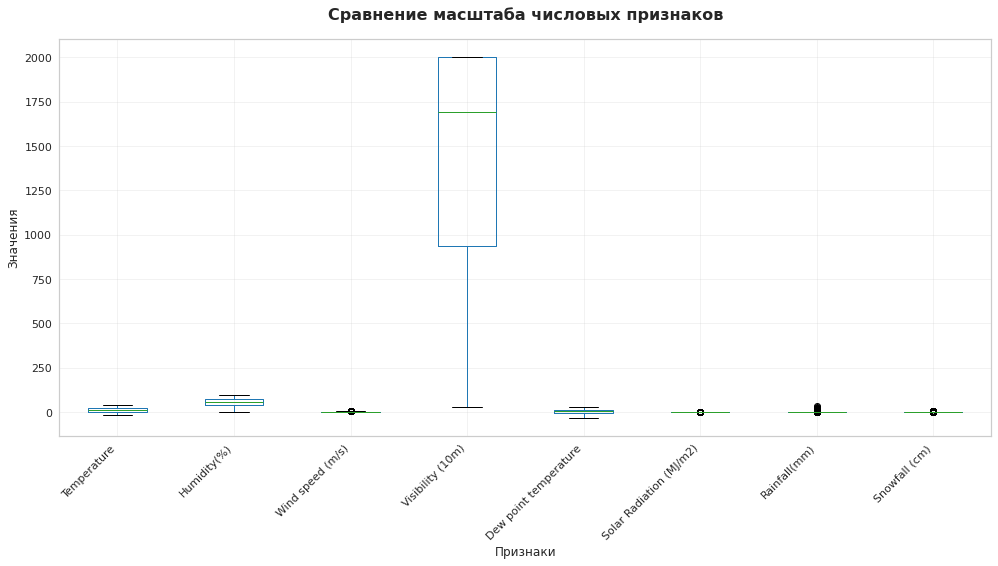

In [22]:
def plot_numerical_boxplots_basic(data, features, figsize=(14, 8),
                              title="Сравнение масштаба числовых признаков"):
    
    # Проверяем, что все указанные признаки есть в данных
    missing_features = [f for f in features if f not in data.columns]
    if missing_features:
        raise ValueError(f"Следующие признаки отсутствуют в данных: {missing_features}")
    
    
    # Создаём фигуру и график
    fig, ax = plt.subplots(figsize=figsize)
    
    # Строим боксплоты для выбранных признаков
    data[features].boxplot(ax=ax, showfliers=True)
    
    # Настройка оформления
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Признаки', fontsize=12)
    ax.set_ylabel('Значения', fontsize=12)
    plt.xticks(rotation=45, ha='right')  # Поворот подписей для лучшей читаемости
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Использование
plot_numerical_boxplots_basic(train_df, num_features)

Наблюдается существенное различие в масштабе признаков, особенно в поле с видимостью. Для деревьев это несущественно, но для kNN критично.


=== АНАЛИЗ ПРИЗНАКА: Seasons ===
Всего наблюдений: 6997
Уникальных категорий: 4
Распределение по категориям:
  Autumn: 1767 (25.3%)
  Spring: 1756 (25.1%)
  Summer: 1741 (24.9%)
  Winter: 1733 (24.8%)


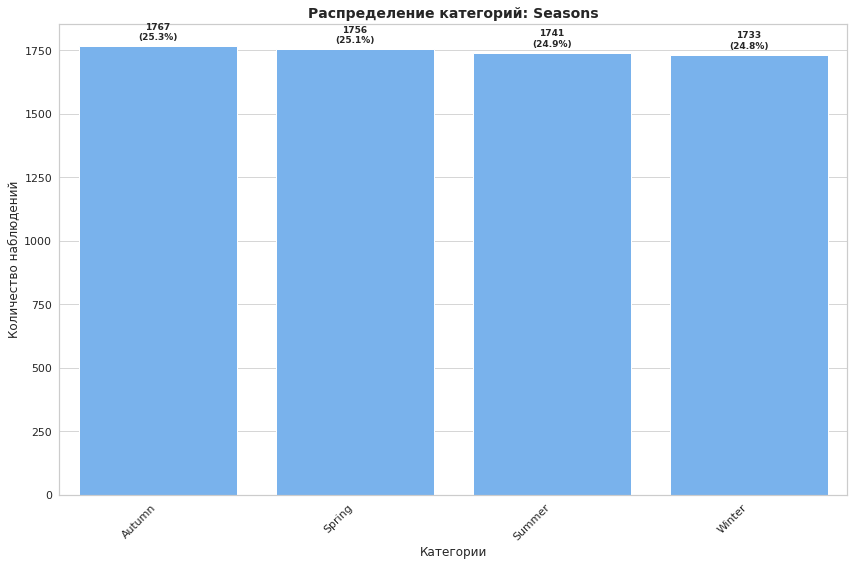


=== АНАЛИЗ ПРИЗНАКА: Holiday ===
Всего наблюдений: 6997
Уникальных категорий: 2
Распределение по категориям:
  No Holiday: 6657 (95.1%)
  Holiday: 340 (4.9%)


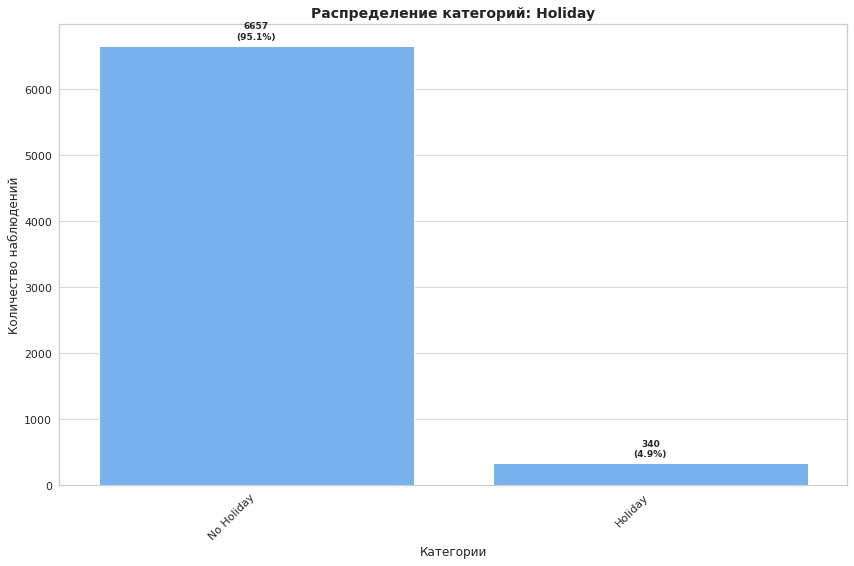


=== АНАЛИЗ ПРИЗНАКА: Functioning Day ===
Всего наблюдений: 6997
Уникальных категорий: 2
Распределение по категориям:
  Yes: 6757 (96.6%)
  No: 240 (3.4%)


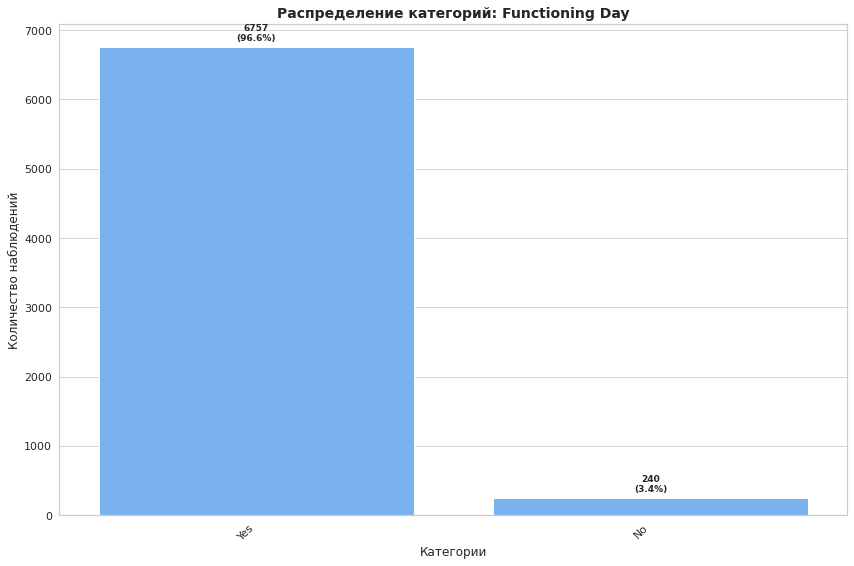

In [23]:
def plot_categorical_distribution(feature_name, data):
    """Функция для построения вертикальной столбчатой диаграммы с дополнительной статистикой"""
    print(f"\n=== АНАЛИЗ ПРИЗНАКА: {feature_name} ===")
    print(f"Всего наблюдений: {len(data[feature_name])}")
    print(f"Уникальных категорий: {data[feature_name].nunique()}")
    
    # Распределение категорий
    value_counts = data[feature_name].value_counts()
    value_percentages = data[feature_name].value_counts(normalize=True) * 100
    
    print("Распределение по категориям:")
    for category, count, percentage in zip(value_counts.index, value_counts.values, value_percentages.values):
        print(f"  {category}: {count} ({percentage:.1f}%)")
    
    
    # Визуализация — вертикальная диаграмма
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=ax, color='#66B2FF')
    
    
    # Подписи значений сверху столбцов
    for i, v in enumerate(value_counts.values):
        ax.text(i, v + value_counts.values.max() * 0.01, f'{v}\n({value_percentages.iloc[i]:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    
    ax.set_title(f'Распределение категорий: {feature_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Категории', fontsize=12)
    ax.set_ylabel('Количество наблюдений', fontsize=12)
    
    # Поворот подписей оси X, если категорий много или они длинные
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Построение графиков для каждого категориального признака
for feature in cat_features:
    plot_categorical_distribution(feature, train_df)

**Детальный разбор**

- Seasons — равномерное распределение, идеальный признак
4 сезона, доли почти одинаковые: по ~25% каждый.
Нет перекосов: ни один сезон не доминирует, ни один не почти отсутствует.
- Holiday — сильный дисбаланс (95% / 5%). 95.1% — обычные дни, всего 4.9% — праздники.
Это классический случай редкого события.
- Functioning Day — ещё более сильный дисбаланс (96.6% / 3.4%). 96.6% — рабочие дни, 3.4% — нерабочие. По смыслу часто сильно коррелирует с Holiday, но не полностью совпадает (могут быть выходные, технические простои и т. п.).

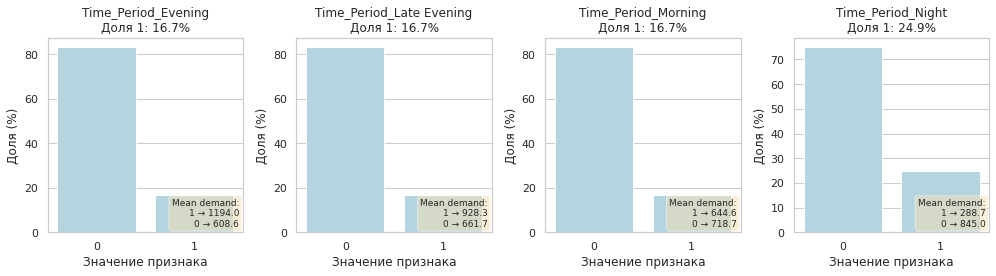

,feature,count_1,pct_1,mean_target_when_1,std_target_when_1,mean_target_when_0,std_target_when_0
0,Time_Period_Evening,1168,16.692868,1193.979452,857.754825,608.580031,545.121636
1,Time_Period_Late Evening,1171,16.735744,928.293766,693.900062,661.680227,627.172525
2,Time_Period_Morning,1171,16.735744,644.608881,570.627851,718.699622,660.026385
3,Time_Period_Night,1745,24.939260,288.704871,265.139998,845.047791,675.479226


In [24]:
def analyze_binary_features(df, binary_cols, target='Rented Bike Count', figsize=(14, 4)):
    
    sns.set(style="whitegrid")
    
    # Проверка, что колонки существуют
    missing_cols = [c for c in binary_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Следующие колонки не найдены в датасете: {missing_cols}")
    
    stats_list = []
    
    n_plots = len(binary_cols)
    if n_plots == 0:
        print("Нет бинарных колонок для анализа.")
        return pd.DataFrame()
    
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    # Если колонка одна, axes не будет списком — приводим к списку для единообразия
    if n_plots == 1:
        axes = [axes]
    
    for i, col in enumerate(binary_cols):
        ax = axes[i]
        
        # --- Статистика ---
        total = len(df)
        count_1 = df[col].sum()
        count_0 = total - count_1
        pct_1 = count_1 / total * 100
        pct_0 = count_0 / total * 100
        
        mean_target_1 = df.loc[df[col] == 1, target].mean()
        mean_target_0 = df.loc[df[col] == 0, target].mean()
        std_target_1 = df.loc[df[col] == 1, target].std()
        std_target_0 = df.loc[df[col] == 0, target].std()
        
        stats_list.append({
            'feature': col,
            'count_1': count_1,
            'pct_1': pct_1,
            'mean_target_when_1': mean_target_1,
            'std_target_when_1': std_target_1,
            'mean_target_when_0': mean_target_0,
            'std_target_when_0': std_target_0
        })
        
        # --- Визуализация: доля 1 и сравнение среднего спроса ---
        # Бар-чарт доли единиц
        sns.barplot(
            x=[0, 1],
            y=[pct_0, pct_1],
            ax=ax,
            color = 'lightblue'
        )
        ax.set_title(f"{col}\nДоля 1: {pct_1:.1f}%")
        ax.set_xlabel("Значение признака")
        ax.set_ylabel("Доля (%)")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['0', '1'])
        
        # Добавляем текст со средним спросом
        text_str = (f"Mean demand:\n1 → {mean_target_1:.1f}\n0 → {mean_target_0:.1f}")
        ax.text(
            0.98, 0.02, text_str,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        )
    
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(stats_list)

stats_df = analyze_binary_features(train_df, bin_features, target='Rented Bike Count')
stats_df

1. Ночь — самый низкий спрос, но и самая стабильная группа  
Time_Period_Night: средний спрос всего 288.7 при доле 24.9 %.  
При этом стандартное отклонение (265.1) — самое маленькое среди всех периодов.  
Ночью спрос стабильно низкий, почти без резких всплесков. Это очень предсказуемый режим.

2. Вечер — самый высокий спрос и самая высокая волатильность  
Time_Period_Evening: средний спрос 1194.0 — это почти в 2 раза выше, чем днём/ночью.  
Но и std = 857.8 — огромный разброс: бывают и «тихие» вечера, и «аншлаги».  
Вечер — ключевой период для бизнеса. Модель должна уметь предсказывать эти пики, но из‑за высокой дисперсии метрики (MAE/RMSE) здесь будут хуже, чем в других периодах.

3. Поздний вечер и утро — противоположные профили  
Late Evening: средний спрос 928.3 (высокий), но чуть ниже, чем в обычный вечер, и чуть меньше разброс.  
Morning: средний спрос 644.6 — ниже, чем в Late Evening, и даже чуть ниже общего среднего по «не‑утренним» дням (718.7).  
Смысл: утро не является «пиковым» временем в этом датасете, несмотря на типичные ожидания.  

4. Доли периодов почти одинаковые (кроме ночи)  
Вечер, поздний вечер и утро: все примерно по 16.7 %.  
Ночь заметно больше: 24.9 % — это важно, потому что модель будет чаще видеть этот режим, и он будет сильнее влиять на общие метрики.  

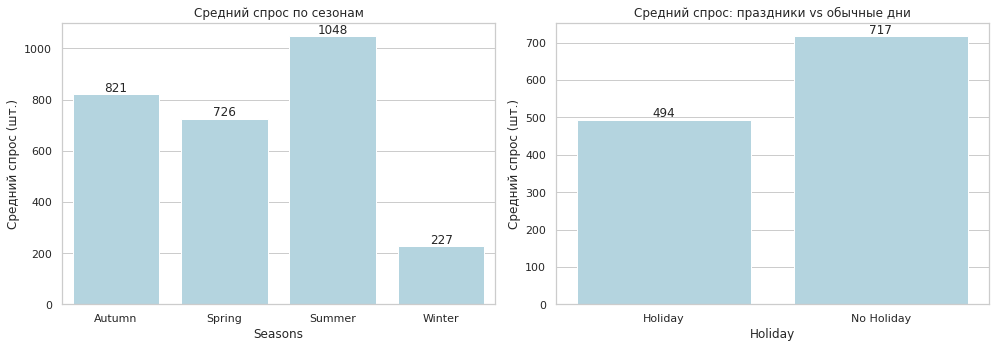

In [25]:
def compare_season_and_holiday_demand(df, target='Rented Bike Count'):
    # 1. Спрос по сезонам
    season_stats = (
        df.groupby('Seasons')[target]
          .agg(['mean', 'std', 'count'])
          .rename(columns={'mean': 'mean_demand', 'std': 'std_demand', 'count': 'n_obs'})
          .reset_index()
    )
    
    # 2. Спрос по праздникам
    holiday_stats = (
        df.groupby('Holiday')[target]
          .agg(['mean', 'std', 'count'])
          .rename(columns={'mean': 'mean_demand', 'std': 'std_demand', 'count': 'n_obs'})
          .reset_index()
    )
    
    # 3. Комбинированный срез: спрос в праздники внутри каждого сезона
    season_holiday_stats = (
        df.groupby(['Seasons', 'Holiday'])[target]
          .agg(['mean', 'std', 'count'])
          .rename(columns={'mean': 'mean_demand', 'std': 'std_demand', 'count': 'n_obs'})
          .reset_index()
    )
    
    # Визуализация
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # Бар-чарт по сезонам
    sns.barplot(data=season_stats, x='Seasons', y='mean_demand', ax=axs[0], color = 'lightblue')
    axs[0].set_title('Средний спрос по сезонам')
    axs[0].set_ylabel('Средний спрос (шт.)')
    for i, row in season_stats.iterrows():
        axs[0].text(i, row['mean_demand'], f"{row['mean_demand']:.0f}", ha='center', va='bottom')
    
    # Бар-чарт по праздникам
    sns.barplot(data=holiday_stats, x='Holiday', y='mean_demand', ax=axs[1], color = 'lightblue')
    axs[1].set_title('Средний спрос: праздники vs обычные дни')
    axs[1].set_ylabel('Средний спрос (шт.)')
    for i, row in holiday_stats.iterrows():
        axs[1].text(i, row['mean_demand'], f"{row['mean_demand']:.0f}", ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return season_stats, holiday_stats, season_holiday_stats

# Запуск
season_stats, holiday_stats, season_holiday_stats = compare_season_and_holiday_demand(train_df)

**Промежуточныйы вывод**

По графикам можно наблюдать вполне естественную картину:
- Летом самый высокий спрос, осень и весна показывают примерно одинаковые значения, но при этом меньше чем летом. Зима, как и ожидалось показывает наименьший спрос

### Анализ корреляций

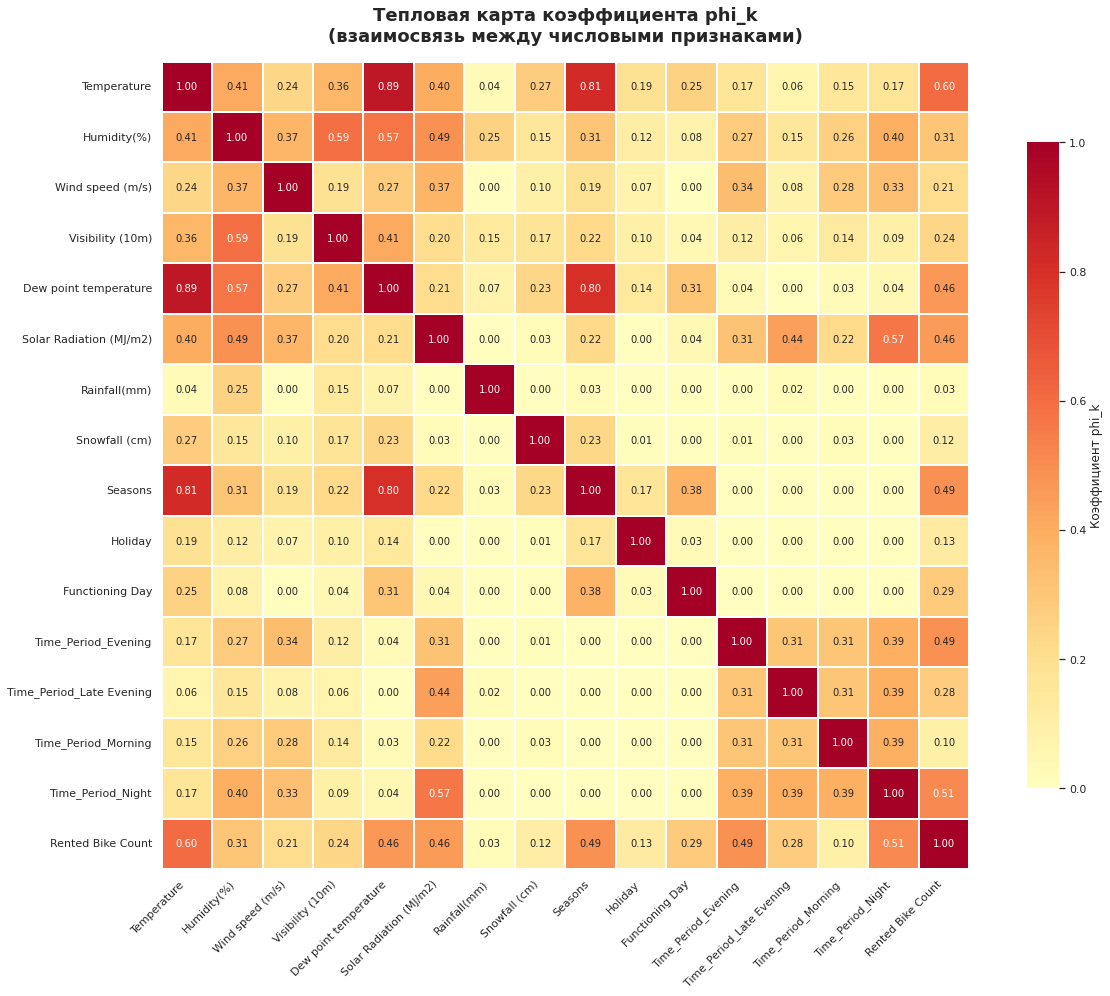

СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.5):
Temperature ↔ Dew point temperature: 0.892
Temperature ↔ Seasons: 0.814
Dew point temperature ↔ Seasons: 0.800
Temperature ↔ Rented Bike Count: 0.603
Humidity(%) ↔ Visibility (10m): 0.586
Humidity(%) ↔ Dew point temperature: 0.571
Solar Radiation (MJ/m2) ↔ Time_Period_Night: 0.566
Time_Period_Night ↔ Rented Bike Count: 0.509


In [26]:
# Вычисляем матрицу корреляций
correlation_matrix = train_df.phik_matrix(
    interval_cols=['Temperature',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Dew point temperature',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)',
    'Rented Bike Count'
    ]
)

# Создаём фигуру с увеличенным размером
plt.figure(figsize=(18, 14))

# Тепловая карта с улучшенной читаемостью
heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',  # Красная-жёлтая-синяя палитра (обратная)
    center=0,  # Центрируем цветовую шкалу на 0
    linewidths=0.3,
    linecolor='white',  # Цвет линий между ячейками
    cbar=True,  # Показываем цветовую шкалу
    cbar_kws={'label': 'Коэффициент phi_k', 'shrink': 0.8},
    square=True,
    annot_kws={'size': 10}  # Размер шрифта аннотаций
)

# Настройка заголовка
plt.title(
    'Тепловая карта коэффициента phi_k\n(взаимосвязь между числовыми признаками)',
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Поворот меток осей для лучшей читаемости
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Оптимизация расположения элементов
plt.tight_layout()
plt.show()


print("СИЛЬНЫЕ КОРРЕЛЯЦИИ (|phi_k| > 0.5):")
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) >= 0.5:
            strong_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

if strong_corr:
    for col1, col2, corr in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"{col1} ↔ {col2}: {corr:.3f}")
else:
    print("Сильных корреляций не обнаружено")

**Вывод по корреляциям**

- Temperature ↔ Dew point temperature (0.892): точка росы почти полностью определяется температурой и влажностью. Это не «новый сигнал», а переформулировка уже имеющейся информации.


- Temperature ↔ Seasons (0.814) и Dew point ↔ Seasons (0.800): сезонность почти полностью объясняет типичную температуру и точку росы. То есть Seasons — это сильный агрегированный признак, который уже «содержит» большую часть информации о температуре.


- Temperature ↔ Rented Bike Count: 0.603 Это один из самых сильных прямых сигналов для прогноза спроса.


Положительная корреляция: чем теплее, тем выше спрос (что логично для проката велосипедов).

- Humidity(%) ↔ Visibility (10m): 0.586 и Humidity(%) ↔ Dew point temperature: 0.571
Здесь тоже много перекрытия информации:

Влажность сильно связана с видимостью (туман, дымка) и с точкой росы.

- Solar Radiation ↔ Time_Period_Night: 0.566
Это не «ошибка», а физическая закономерность: ночью солнечной радиации почти нет, днём — есть.


- Time_Period_Night ↔ Rented Bike Count: 0.509
Сильная отрицательная связь (скорее всего, потому что ночью спрос низкий):


### Общий вывод по разделу

**Данные**

- Объём данных достаточный: 6997 строк после очистки от неполных дубликатов — этого хватает для надёжной кросс‑валидации и подбора гиперпараметров (в т. ч. через Optuna).

- Разнообразие типов признаков (числовые, категориальные, бинарные) — идеально под ColumnTransformer + пайплайн: можно отдельно обрабатывать пропуски, кодировать категории и масштабировать числа.

- Нет пропусков в целевой переменной и ключевых категориальных признаках — это повышает чистоту эксперимента и интерпретируемость результатов.

**Закономерности спроса**

- Сезонность — один из главных драйверов: летом спрос максимальный (mean ≈ 1046), зимой — в 3–4 раза ниже (mean ≈ 226) и гораздо стабильнее.

- Время суток сильно меняет профиль спроса: Вечер — пик спроса (mean ≈ 1194), но с высокой волатильностью (std ≈ 858): нужны модели, устойчивые к выбросам и способные ловить пики. Ночь — низкий и очень стабильный спрос (mean ≈ 289, std ≈ 265): здесь прогноз будет проще. Утро оказалось не пиковым временем (mean ≈ 645), что важно учитывать при интерпретации.

- Температура — сильный предиктор (корреляция с целевым признаком ≈ 0.603): чем теплее, тем выше спрос. Осадки и снег типично снижают спрос; при этом сами признаки имеют много нулей и сильную правостороннюю асимметрию — нужна корректная обработка 

**Проблемы и риски для модели**

- Сильные корреляции между признаками (мультиколлинеарность): Temperature ↔ Dew point temperature (0.892) и обе тесно связаны с Seasons. Для линейных моделей это критично: лучше оставить 1–2 из них, а не все три. Humidity(%) сильно связана с Visibility и Dew point — тоже избыточность. Solar Radiation и Time_Period_Night отражают одну и ту же идею «освещённости/времени суток»: не стоит ожидать от модели двух независимых эффектов.

- Дисбаланс редких категорий: Holiday (4.9 %) и Functioning Day (3.4 % нерабочих) — нужно аккуратно оценивать качество на этих подвыборках (стратифицированные метрики).

- Скошенные распределения и много нулей у осадков, снега, солнечной радиации — для линейных моделей и kNN это критично; для деревьев менее критично, но трансформации всё равно улучшают стабильность.

## Анализ тестовых данных на соответствие тренировочным


In [27]:
display(test_df.head(5))
display(test_df.info())
display(test_df.shape)
display(test_df.columns)
display(test_df.describe())

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   object 
 9   Holiday                   1752 non-null   object 
 10  Functioning Day           1752 non-null   object 
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Per

None

(1752, 16)

Index(['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
       'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day',
       'Time_Period_Evening', 'Time_Period_Late Evening',
       'Time_Period_Morning', 'Time_Period_Night', 'Rented Bike Count'],
      dtype='object')

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,1752.000000,1680.000000,1700.000000,1680.000000,1752.000000,1700.000000,1688.000000,1691.000000,1752.000000
mean,13.162957,58.172619,1.737000,1442.061905,4.283105,0.578035,0.145794,0.078001,700.586187
std,12.024380,20.602653,1.013244,613.892076,13.169451,0.887957,0.920346,0.438827,639.880816
min,-17.800000,0.000000,0.000000,34.000000,-29.200000,0.000000,0.000000,0.000000,0.000000
25%,3.900000,42.000000,1.000000,942.750000,-4.500000,0.000000,0.000000,0.000000,194.750000
50%,14.450000,57.000000,1.600000,1723.500000,5.800000,0.020000,0.000000,0.000000,503.500000
75%,22.900000,74.000000,2.300000,2000.000000,15.100000,0.910000,0.000000,0.000000,1042.000000
max,37.900000,98.000000,5.600000,2000.000000,27.200000,3.420000,15.500000,7.100000,3380.000000


Визуально тестовый датафрейм идентичен по структуре тренировочному, напишем функцию, чтобы наверняка проверить

In [28]:
def check_train_test_compatibility(train_df, test_df, target_col='Rented Bike Count'):
    
    issues = []

    # 1. Проверка колонок (кроме целевой)
    train_cols = [c for c in train_df.columns if c != target_col]
    test_cols = [c for c in test_df.columns if c != target_col]

    if set(train_cols) != set(test_cols):
        issues.append(f"Разные наборы колонок: train={set(train_cols)}, test={set(test_cols)}")

    if train_cols != test_cols:
        issues.append("Порядок колонок отличается. Для пайплайна лучше привести к одному порядку.")
        # Приводим тест к порядку train (без target)
        test_df = test_df[train_cols + ([target_col] if target_col in test_df.columns else [])]

    # 2. Проверка типов данных по колонкам
    for col in train_cols:
        if col not in test_df.columns:
            issues.append(f"Колонка '{col}' есть в train, но отсутствует в test")
            continue
        train_dtype = train_df[col].dtype
        test_dtype = test_df[col].dtype
        if not np.issubdtype(train_dtype, np.number) and not np.issubdtype(test_dtype, np.number):
            # Для нечисловых: сравниваем как строки
            if str(train_dtype) != str(test_dtype):
                issues.append(f"Разные типы для '{col}': train={train_dtype}, test={test_dtype}")

    # 3. Проверка категориальных уровней: в тесте не должно быть новых категорий
    cat_candidates = ['Seasons','Holiday','Functioning Day'] 
    for col in cat_candidates:
        if col not in train_cols or col not in test_df.columns:
            continue
        train_levels = set(train_df[col].dropna().unique())
        test_levels = set(test_df[col].dropna().unique())
        new_in_test = test_levels - train_levels
        if new_in_test:
            issues.append(f"В тесте есть новые категории для '{col}': {new_in_test}")

    # 4. Сравнение доли пропусков по числовым признакам
    num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != target_col and c in test_df.columns]

    for col in num_cols:
        train_nan_ratio = train_df[col].isna().mean()
        test_nan_ratio = test_df[col].isna().mean()
        diff = abs(train_nan_ratio - test_nan_ratio)
        if diff > 0.05:  
            issues.append(
                f"Сильное расхождение доли пропусков в '{col}': "
                f"train={train_nan_ratio:.3f}, test={test_nan_ratio:.3f}, diff={diff:.3f}"
            )

    return issues, test_df

In [29]:
issues, test_df_fixed = check_train_test_compatibility(train_df, test_df)

if issues:
    print("Найдены проблемы:")
    for i in issues:
        print("-", i)
else:
    print("Тестовый датасет совместим с тренировочным.")

Тестовый датасет совместим с тренировочным.


Для большей уверенности визуальзируем распределение числовых признаков в датасетах

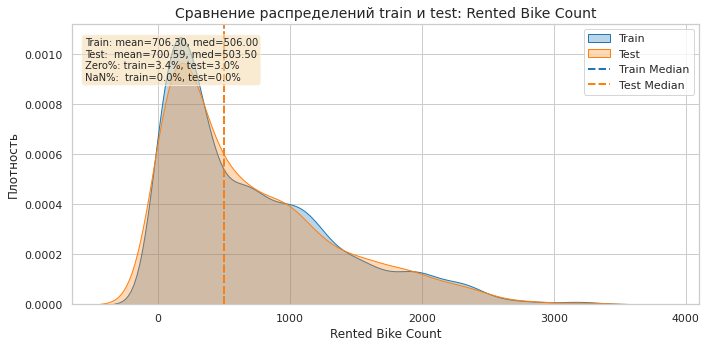

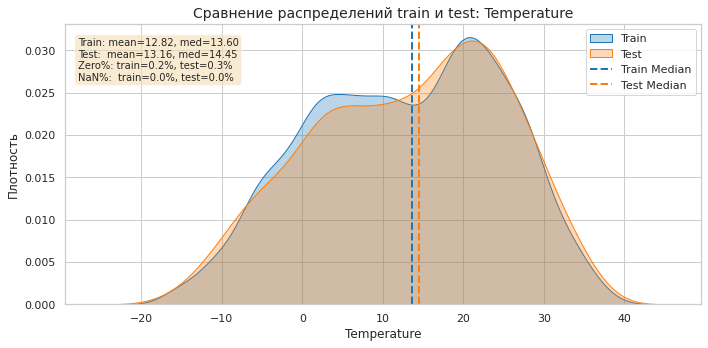

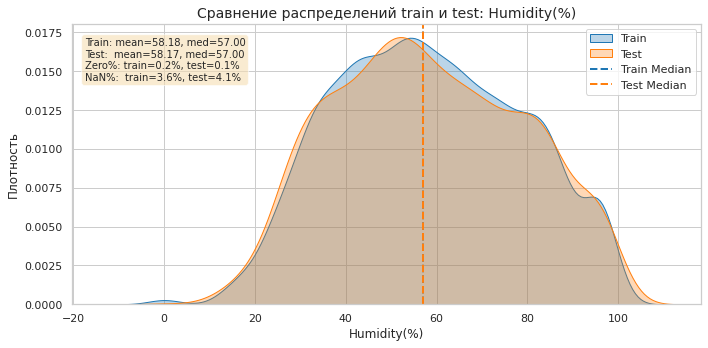

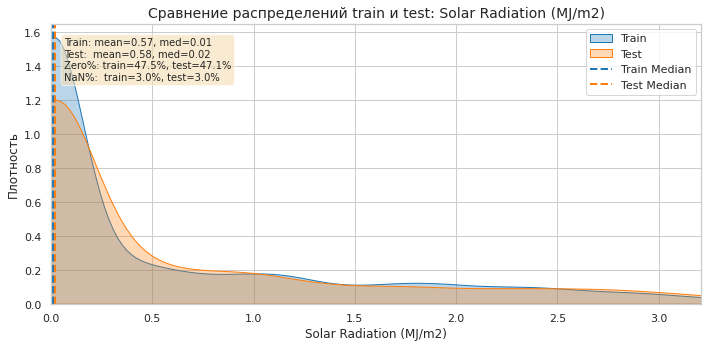

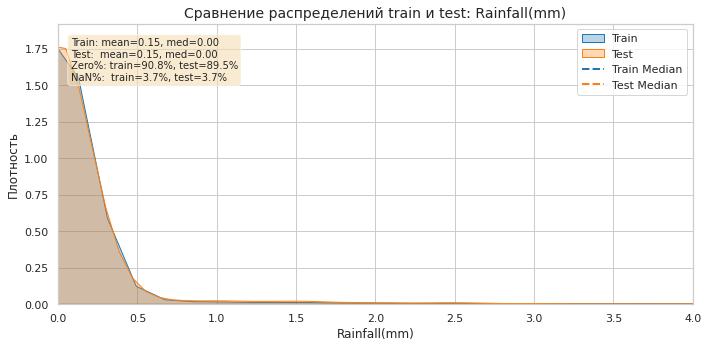

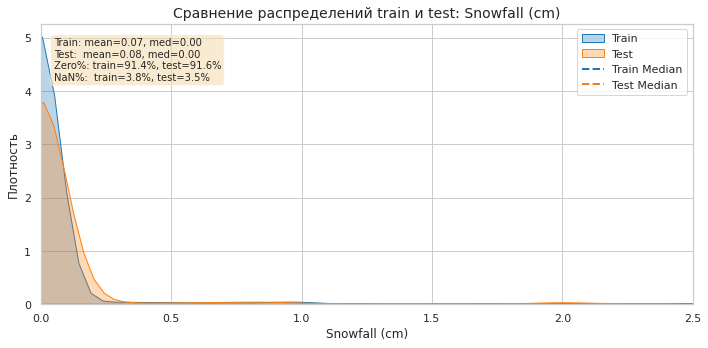

In [30]:
features_to_compare = [
    'Rented Bike Count',
    'Temperature',
    'Humidity(%)',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)'
]

def plot_train_test_kde_enhanced(train_df, test_df, features, figsize=(10, 5)):
    sns.set_style("whitegrid")
    
    for feature in features:
        # Защита: проверяем наличие колонки
        if feature not in train_df.columns or feature not in test_df.columns:
            print(f"⚠️ Пропущено: колонка '{feature}' отсутствует в train или test")
            continue
        
        plt.figure(figsize=figsize)
        
        # KDE
        sns.kdeplot(data=train_df, x=feature, label='Train', fill=True, alpha=0.3, color='#1f77b4')
        sns.kdeplot(data=test_df, x=feature, label='Test', fill=True, alpha=0.3, color='#ff7f0e')
        
        # Статистика
        train_mean = train_df[feature].mean()
        train_median = train_df[feature].median()
        test_mean = test_df[feature].mean()
        test_median = test_df[feature].median()
        
        train_nan_pct = train_df[feature].isna().mean() * 100
        test_nan_pct = test_df[feature].isna().mean() * 100
        
        train_zero_pct = (train_df[feature] == 0).mean() * 100
        test_zero_pct = (test_df[feature] == 0).mean() * 100
        
        stats_text = (
            f"Train: mean={train_mean:.2f}, med={train_median:.2f}\n"
            f"Test:  mean={test_mean:.2f}, med={test_median:.2f}\n"
            f"Zero%: train={train_zero_pct:.1f}%, test={test_zero_pct:.1f}%\n"
            f"NaN%:  train={train_nan_pct:.1f}%, test={test_nan_pct:.1f}%"
        )
        plt.text(0.02, 0.95, stats_text, transform=plt.gca().transAxes,
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
        
        # Линии медиан
        plt.axvline(train_median, color='#1f77b4', linestyle='--', linewidth=2, label=f'Train Median')
        plt.axvline(test_median, color='#ff7f0e', linestyle='--', linewidth=2, label=f'Test Median')
        
        # Обрезаем хвосты для читаемости у скошенных признаков
        if feature in ['Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']:
            upper_limit = max(
                train_df[feature].quantile(0.99),
                test_df[feature].quantile(0.99)
            )
            plt.xlim(left=0, right=upper_limit)
        
        plt.title(f'Сравнение распределений train и test: {feature}', fontsize=14)
        plt.xlabel(feature, fontsize=12)
        plt.ylabel('Плотность', fontsize=12)
        
        # Убираем дубли в легенде (Train/Test + Train Median/Test Median)
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), loc='best')
        
        plt.tight_layout()
        plt.show()

plot_train_test_kde_enhanced(train_df, test_df, features_to_compare)

**Вывод по анализу сравнения данных**

Датасеты полностью совместимы по структуре, количеству и названиям признаков и типам данных. Обученная на тренировочном датасете модель будет исправно работать на тестовых данных.



---



## Подготовка к обучению

### Разделение и сортировка данных 

Нам уже предоставлен тренировочный датасет, поэтому делить на выборки не будем

In [31]:
# train_df — твой датасет
df = train_df.copy()

# Целевая переменная
y_train = df['Rented Bike Count']
X_train = df.drop(columns=['Rented Bike Count'])

Создадим кастомный трансформер который:

- создаёт Seasons_grouped: частые сезоны остаются, остальные становятся Other;

- делает is_peak_hour = 1, если период Evening или Late Evening, иначе 0;
удаляет исходные колонки Time_Period_*

In [32]:
class BikeFeaturesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, season_threshold=0.05):
        self.season_threshold = season_threshold
        self.common_seasons_ = None

    def fit(self, X, y=None):
        # Определяем частые категории для Seasons
        counts = X['Seasons'].value_counts(normalize=True)
        self.common_seasons_ = counts[counts >= self.season_threshold].index.tolist()
        return self

    def transform(self, X):
        X_out = X.copy()

        # Группируем редкие сезоны в 'Other'
        X_out['Seasons_grouped'] = X_out['Seasons'].apply(
            lambda s: s if s in self.common_seasons_ else 'Other'
        )

        # Создаём признак пика спроса: Evening или Late Evening
        X_out['is_peak_hour'] = (
            X_out['Time_Period_Evening'] | X_out['Time_Period_Late Evening']
        ).astype(int)

        # Удаляем исходные бинарные колонки времени
        time_cols = [c for c in X_out.columns if c.startswith('Time_Period_')]
        X_out = X_out.drop(columns=time_cols)

        return X_out

In [33]:
#Переопределяем списки признаков под выход трансформера
num_features = [
    'is_peak_hour',
    'Temperature',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Dew point temperature',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)'
]

# Теперь используем Seasons_grouped вместо Seasons
cat_features = [
    'Seasons_grouped',
    'Holiday',
    'Functioning Day'
]

### Создание пайплайнов

In [34]:
num_pipeline_knn = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),     
    ('scaler', StandardScaler())
])


cat_pipeline_knn = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipeline_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=-999))     
])


cat_pipeline_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_knn = ColumnTransformer(
    transformers = [
        ('num', num_pipeline_knn, num_features),
        ('cat', cat_pipeline_knn, cat_features)
    ], remainder = 'drop'
)

preprocessor_tree = ColumnTransformer(
    transformers = [
        ('num', num_pipeline_tree, num_features),
        ('cat', cat_pipeline_tree, cat_features)
    ], remainder = 'drop'
)

In [35]:
pipeline_base_knn = Pipeline(steps=[
    ('custom', BikeFeaturesTransformer()),
    ('preprocessor_knn', preprocessor_knn),
    ('model', KNeighborsRegressor())
])

pipeline_base_tree = Pipeline(steps=[
    ('custom', BikeFeaturesTransformer()),
    ('preprocessor_tree', preprocessor_tree),
    ('model', DecisionTreeRegressor(random_state=42))
])

### Обучение и кросс-валидация базовых моделей

In [36]:
pipeline_base_knn.fit(X_train, y_train)
pipeline_base_tree.fit(X_train, y_train)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [37]:
scores = {
        'neg_rmse': 'neg_root_mean_squared_error',
        'neg_mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    }
# Для kNN
knn_base_cv = cross_validate(
    pipeline_base_knn, 
    X_train, 
    y_train, 
    cv=cv,
    scoring=scores,
    n_jobs=-1
)

# Для Decision Tree
tree_base_cv = cross_validate(
    pipeline_base_tree,
    X_train, 
    y_train, 
    cv=cv,
    scoring=scores,
    n_jobs=-1
)

# Рассчитываем метрики
knn_metrics = {
    'RMSE': -knn_base_cv['test_neg_rmse'].mean(),
    'MAE': -knn_base_cv['test_neg_mae'].mean(),
    'R2': knn_base_cv['test_r2'].mean()
}

tree_metrics = {
    'RMSE': -tree_base_cv['test_neg_rmse'].mean(),
    'MAE': -tree_base_cv['test_neg_mae'].mean(),
    'R2': tree_base_cv['test_r2'].mean()
}

# Таблица сравнения
print("\n" + "="*60)
print("БАЗОВЫЕ МОДЕЛИ (кросс-валидация)")
print("="*60)

base_cv_df = pd.DataFrame({
    'Модель': ['kNN (базовый)', 'Decision Tree (базовый)', 'Linear Regression заказчика'],
    'RMSE_cv': [knn_metrics['RMSE'], tree_metrics['RMSE'], train_rmse],
    'MAE_cv': [knn_metrics['MAE'], tree_metrics['MAE'], train_mae],
    'R2_cv': [knn_metrics['R2'], tree_metrics['R2'], train_r2]
})

print(base_cv_df.round(3).to_string(index=False))
print("="*60)


БАЗОВЫЕ МОДЕЛИ (кросс-валидация)
                     Модель  RMSE_cv  MAE_cv  R2_cv
              kNN (базовый)  341.217 226.750  0.720
    Decision Tree (базовый)  401.403 253.751  0.613
Linear Regression заказчика  412.526 309.078  0.593


**Промежуточный вывод**

Нами были обучены две модели: kNN и Decision Tree без подбора гиперпараметров. Кроссвалидация показала довольно низкое качество обеих моделей. Но при этом все равно лучшее по сравнению с линейной моделью заказчика.

## Подбор гиперпараметров

### Объявление функций

In [38]:
def objective_knn(trial):
    # Подбираем гиперпараметры для KNN
    n_neighbors = trial.suggest_int('n_neighbors', 3, 30)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan'])

    # Пересоздаём пайплайн с текущими параметрами
    pipeline_knn = Pipeline(steps=[
        ('custom', BikeFeaturesTransformer()),
        ('preprocessor_knn', preprocessor_knn),
        ('model', KNeighborsRegressor(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric
        ))
    ])

    scores = cross_val_score(
        pipeline_knn, X_train, y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    return scores.mean()  # Optuna максимизирует: чем меньше RMSE, тем лучше


def objective_tree(trial):
    # Подбираем гиперпараметры для Decision Tree
    max_depth = trial.suggest_int('max_depth', 3, 20, step=1)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    pipeline_tree = Pipeline(steps=[
        ('custom', BikeFeaturesTransformer()),
        ('preprocessor_tree', preprocessor_tree),
        ('model', DecisionTreeRegressor(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_SEED
        ))
    ])

    scores = cross_val_score(
        pipeline_tree, X_train, y_train,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    return scores.mean()

### Запускаем исследование

In [39]:
# KNN
study_knn = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_knn.optimize(objective_knn, n_trials=50, show_progress_bar=True)
best_knn_params = study_knn.best_params
print("Лучшие параметры KNN:", best_knn_params)

# Decision Tree
study_tree = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study_tree.optimize(objective_tree, n_trials=50, show_progress_bar=True)
best_tree_params = study_tree.best_params
print("Лучшие параметры Decision Tree:", best_tree_params)

[I 2026-07-10 20:26:09,550] A new study created in memory with name: no-name-f03e4d0b-1045-4b16-a8ea-5a9cdfa0586c


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-10 20:26:09,985] Trial 0 finished with value: -341.9649796738703 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: -341.9649796738703.
[I 2026-07-10 20:26:10,896] Trial 1 finished with value: -324.10725619549055 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 1 with value: -324.10725619549055.
[I 2026-07-10 20:26:11,281] Trial 2 finished with value: -348.2648713959305 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 1 with value: -324.10725619549055.
[I 2026-07-10 20:26:11,685] Trial 3 finished with value: -331.8486122245339 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 1 with value: -324.10725619549055.
[I 2026-07-10 20:26:12,641] Trial 4 finished with value: -328.3966793845634 and parameters: {'n_neighbors': 20, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 

[I 2026-07-10 20:26:51,328] A new study created in memory with name: no-name-08b96d28-aa00-4e3c-b91f-e9df2465d98f


[I 2026-07-10 20:26:51,323] Trial 49 finished with value: -323.44848224277064 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 15 with value: -322.96687659190195.
Лучшие параметры KNN: {'n_neighbors': 10, 'weights': 'distance', 'metric': 'manhattan'}


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-10 20:26:51,670] Trial 0 finished with value: -325.7967453638253 and parameters: {'max_depth': 9, 'min_samples_split': 20, 'min_samples_leaf': 8}. Best is trial 0 with value: -325.7967453638253.
[I 2026-07-10 20:26:52,018] Trial 1 finished with value: -366.36245104389803 and parameters: {'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 0 with value: -325.7967453638253.
[I 2026-07-10 20:26:52,259] Trial 2 finished with value: -377.8771996847812 and parameters: {'max_depth': 4, 'min_samples_split': 18, 'min_samples_leaf': 7}. Best is trial 0 with value: -325.7967453638253.
[I 2026-07-10 20:26:52,579] Trial 3 finished with value: -338.26569307505673 and parameters: {'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 0 with value: -325.7967453638253.
[I 2026-07-10 20:26:52,940] Trial 4 finished with value: -375.97247093213804 and parameters: {'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 

- Лучшие параметры KNN: {'n_neighbors': 10, 'weights': 'distance', 'metric': 'manhattan'}

- Лучшие параметры Decision Tree: {'max_depth': 8, 'min_samples_split': 20, 'min_samples_leaf': 8}

### Обновляем пайплайны

In [40]:
# Пайплайны с лучшими параметрами
pipeline_opt_knn = Pipeline(steps=[
    ('custom', BikeFeaturesTransformer()),
    ('preprocessor_knn', preprocessor_knn),
    ('model', KNeighborsRegressor(**best_knn_params))
])

pipeline_opt_tree = Pipeline(steps=[
    ('custom', BikeFeaturesTransformer()),
    ('preprocessor_tree', preprocessor_tree),
    ('model', DecisionTreeRegressor(random_state=RANDOM_SEED, **best_tree_params))
])

# Кросс-валидация
cv_knn_opt = cross_validate(
    pipeline_opt_knn,
    X_train,
    y_train,
    cv=cv,
    scoring=scores,
    n_jobs=-1
)
cv_tree_opt = cross_validate(
    pipeline_opt_tree,
    X_train,
    y_train,
    cv=cv,
    scoring=scores, 
    n_jobs=-1
)

def get_metrics_from_cv(cv_result):
    return {
        'RMSE': -cv_result['test_neg_rmse'].mean(),
        'MAE': -cv_result['test_neg_mae'].mean(),
        'R2': cv_result['test_r2'].mean(),
        'RMSE_std': -cv_result['test_neg_rmse'].std(),
        'MAE_std': -cv_result['test_neg_mae'].std(),
        'R2_std': cv_result['test_r2'].std()
    }

metrics_knn_opt = get_metrics_from_cv(cv_knn_opt)
metrics_tree_opt = get_metrics_from_cv(cv_tree_opt)

### Сравнение метрик 

In [41]:
comparison_df = pd.DataFrame({
    'Модель': [
        'kNN (baseline)',
        'Decision Tree (baseline)',
        'Linear Regression (заказчик)',
        'kNN (оптимизированный)',
        'Decision Tree (оптимизированный)'
    ],
    'RMSE': [
        knn_metrics['RMSE'],
        tree_metrics['RMSE'],
        train_rmse,
        metrics_knn_opt['RMSE'],
        metrics_tree_opt['RMSE']
    ],
    'MAE': [
        knn_metrics['MAE'],
        tree_metrics['MAE'],
        train_mae,
        metrics_knn_opt['MAE'],
        metrics_tree_opt['MAE']
    ],
    'R2': [
        knn_metrics['R2'],
        tree_metrics['R2'],
        train_r2,
        metrics_knn_opt['R2'],
        metrics_tree_opt['R2']
    ]
})

print(comparison_df.round(3).to_string(index=False))

                          Модель    RMSE     MAE    R2
                  kNN (baseline) 341.217 226.750 0.720
        Decision Tree (baseline) 401.403 253.751 0.613
    Linear Regression (заказчик) 412.526 309.078 0.593
          kNN (оптимизированный) 322.967 211.902 0.749
Decision Tree (оптимизированный) 324.537 216.371 0.747


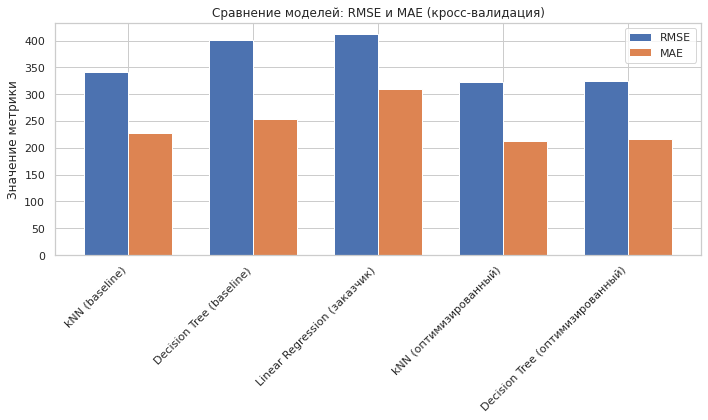

In [42]:
models = comparison_df['Модель']
rmse_vals = comparison_df['RMSE']
mae_vals = comparison_df['MAE']

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, rmse_vals, width, label='RMSE')
ax.bar(x + width/2, mae_vals, width, label='MAE')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение моделей: RMSE и MAE (кросс-валидация)')
plt.tight_layout()
plt.show()

**Промежуточный вывод**

Оптимизированная kNN модель показала наилучшие результаты по метрикам

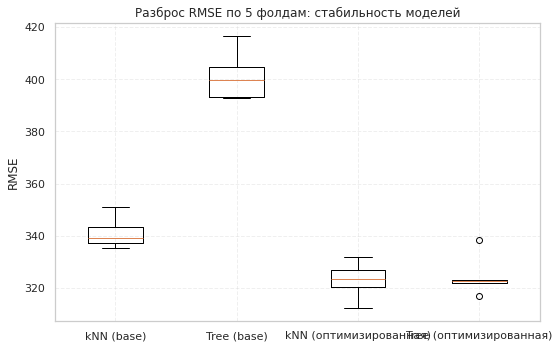

In [43]:
knn_rmse_folds = -cv_knn_opt['test_neg_rmse']
tree_rmse_folds = -cv_tree_opt['test_neg_rmse']
knn_base_rmse_folds = -knn_base_cv['test_neg_rmse']
tree_base_rmse_folds = -tree_base_cv['test_neg_rmse']

plt.figure(figsize=(8, 5))
plt.boxplot(
    [knn_base_rmse_folds, tree_base_rmse_folds, knn_rmse_folds, tree_rmse_folds],
    tick_labels=['kNN (base)', 'Tree (base)', 'kNN (оптимизированная)', 'Tree (оптимизированная)']
)
plt.ylabel('RMSE')
plt.title('Разброс RMSE по 5 фолдам: стабильность моделей')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Оценка важности гиперпараметров

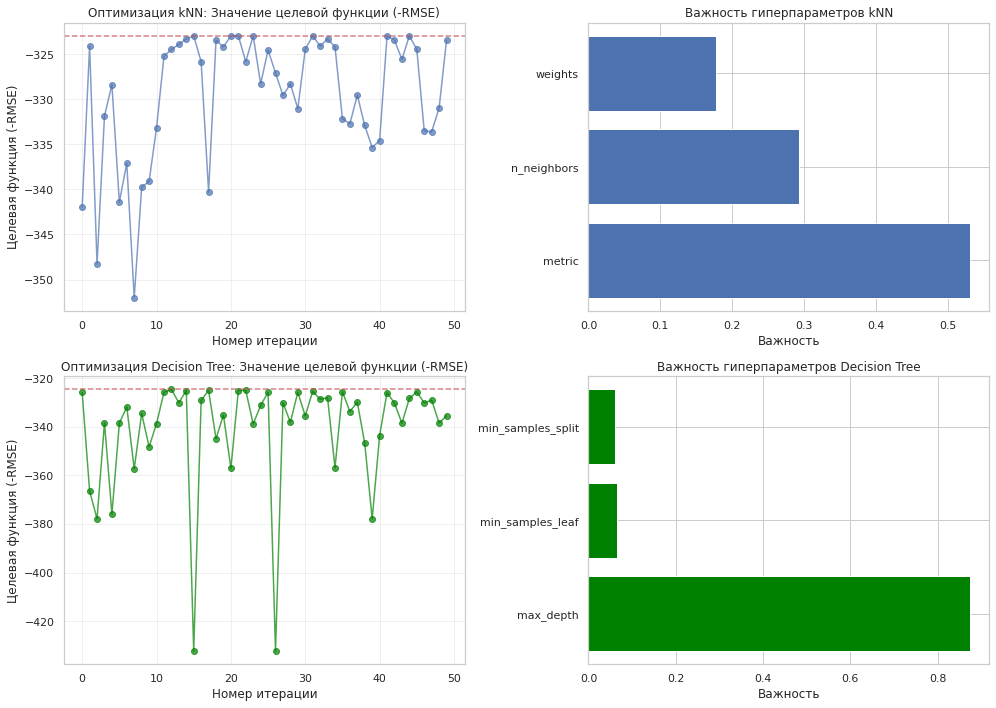

In [44]:
# Визуализация процесса оптимизации
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. История оптимизации kNN
ax1 = axes[0, 0]
ax1.plot(study_knn.trials_dataframe()['number'], 
         study_knn.trials_dataframe()['value'], 
         marker='o', linestyle='-', alpha=0.7)
ax1.axhline(y=study_knn.best_value, color='r', linestyle='--', alpha=0.7)
ax1.set_title('Оптимизация kNN: Значение целевой функции (-RMSE)')
ax1.set_xlabel('Номер итерации')
ax1.set_ylabel('Целевая функция (-RMSE)')
ax1.grid(True, alpha=0.3)

# 2. Важность гиперпараметров kNN
ax2 = axes[0, 1]
importance_knn = optuna.importance.get_param_importances(study_knn)
param_names = list(importance_knn.keys())
importance_values = list(importance_knn.values())
ax2.barh(param_names, importance_values)
ax2.set_title('Важность гиперпараметров kNN')
ax2.set_xlabel('Важность')

# 3. История оптимизации Decision Tree
ax3 = axes[1, 0]
ax3.plot(study_tree.trials_dataframe()['number'], 
         study_tree.trials_dataframe()['value'], 
         marker='o', linestyle='-', alpha=0.7, color='green')
ax3.axhline(y=study_tree.best_value, color='r', linestyle='--', alpha=0.7)
ax3.set_title('Оптимизация Decision Tree: Значение целевой функции (-RMSE)')
ax3.set_xlabel('Номер итерации')
ax3.set_ylabel('Целевая функция (-RMSE)')
ax3.grid(True, alpha=0.3)

# 4. Важность гиперпараметров Decision Tree
ax4 = axes[1, 1]
importance_tree = optuna.importance.get_param_importances(study_tree)
param_names = list(importance_tree.keys())
importance_values = list(importance_tree.values())
ax4.barh(param_names, importance_values, color='green')
ax4.set_title('Важность гиперпараметров Decision Tree')
ax4.set_xlabel('Важность')

plt.tight_layout()
plt.show()

Для kNN выбор метрики является ключевым фактором для качества модели, она вносит свой вклад более чем на 50%. В модели деревьев глубина является основным гиперпараметром, определяющим более 80% вклада.

In [45]:
pipeline_opt_knn.fit(X_train, y_train)
pipeline_opt_tree.fit(X_train, y_train)

Pipeline(steps=[('custom', BikeFeaturesTransformer()),
                ('preprocessor_tree',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=-999,
                                                                                 strategy='constant'))]),
                                                  ['is_peak_hour',
                                                   'Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Seasons_grouped', 'Holiday',
                                                   'Functioning Day'])])),
                ('model',
                 DecisionTreeRegressor(max_depth=8, min_samples_leaf=8,
                                       min_samples_split=20,
                                       random_state=42))])

### Оценка важности признаков

Топ-10 важных признаков:
num__Temperature               0.3530
num__is_peak_hour              0.2308
num__Solar Radiation (MJ/m2)   0.1211
num__Humidity(%)               0.1031
cat__Functioning Day_Yes       0.0758
cat__Seasons_grouped_Winter    0.0360
cat__Functioning Day_No        0.0357
num__Dew point temperature     0.0176
num__Rainfall(mm)              0.0117
cat__Seasons_grouped_Autumn    0.0095


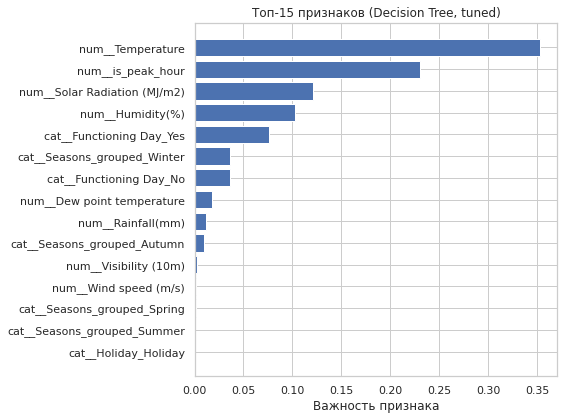

In [46]:
# Получаем имена признаков 
preprocessor = pipeline_opt_tree.named_steps['preprocessor_tree']
X_after_custom = pipeline_opt_tree.named_steps['custom'].transform(X_train)
feature_names = preprocessor.get_feature_names_out()

# Важность из обученной модели
importances = pipeline_opt_tree.named_steps['model'].feature_importances_

# Собираем в DataFrame и сортируем
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)


print("Топ-10 важных признаков:")
for _, row in importance_df.head(10).iterrows():
    print(f"{row['feature']:30} {row['importance']:.4f}")

# Визуализация
top_n = 15
top_imp = importance_df.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(top_imp['feature'].astype(str), top_imp['importance'])
plt.xlabel('Важность признака')
plt.title(f'Топ-{top_n} признаков (Decision Tree, tuned)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

- Температура воздуха — самый значимый фактор (вклад ~35.3%). Спрос сильно зависит от комфортности погоды: при слишком низкой или высокой температуре люди реже берут велосипеды.

- Пиковые часы (is_peak_hour) — второй по важности признак (23.1%). Это отражает типичную городскую динамику: утренние и вечерние часы пик дают основную долю аренд.

- Солнечная радиация и влажность вносят заметный вклад (12.1% и 10.3%), дополняя картину «комфортности» поездки.

- Рабочий день (Functioning Day) — важный контекстный признак: в рабочие дни спрос систематически отличается от выходных.

- Сезонность (зима, осень) и осадки имеют меньший, но стабильный вклад: зимой и в дождливую погоду спрос снижается.

## Оценка лучшей модели на тестовых данных

In [47]:
y_pred_knn = pipeline_opt_knn.predict(X_test)

МЕТРИКИ KNN (tuned) НА ТЕСТОВОЙ ВЫБОРКЕ
RMSE: 319.178
MAE:  211.268
R²:   0.751

Таблица для отчёта:
     Модель    RMSE     MAE    R²
KNN (tuned) 319.178 211.268 0.751


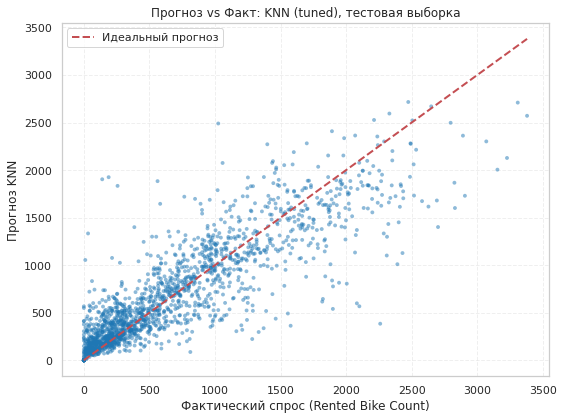

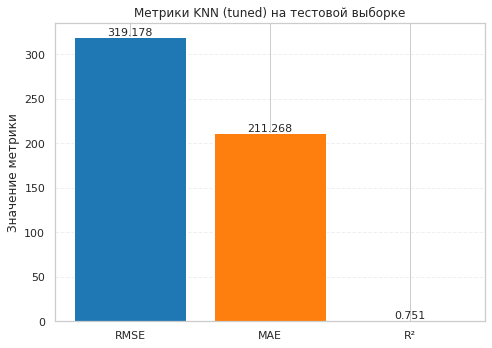

In [48]:
#Расчёт метрик 
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn  = mean_absolute_error(y_test, y_pred_knn)
r2_knn   = r2_score(y_test, y_pred_knn)

print("="*50)
print("МЕТРИКИ KNN (tuned) НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*50)
print(f"RMSE: {rmse_knn:.3f}")
print(f"MAE:  {mae_knn:.3f}")
print(f"R²:   {r2_knn:.3f}")
print("="*50)


results_df = pd.DataFrame({
    'Модель': ['KNN (tuned)'],
    'RMSE': [rmse_knn],
    'MAE':  [mae_knn],
    'R²':   [r2_knn]
})
print("\nТаблица для отчёта:")
print(results_df.round(3).to_string(index=False))


plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.5, s=15, color='#1f77b4', edgecolors='none')

min_val = min(y_test.min(), y_pred_knn.min())
max_val = max(y_test.max(), y_pred_knn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальный прогноз')

plt.xlabel('Фактический спрос (Rented Bike Count)')
plt.ylabel('Прогноз KNN')
plt.title('Прогноз vs Факт: KNN (tuned), тестовая выборка')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


metrics = ['RMSE', 'MAE', 'R²']
values = [rmse_knn, mae_knn, r2_knn]

plt.figure(figsize=(7, 5))
bars = plt.bar(metrics, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])


for bar, val in zip(bars, values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}',
             ha='center', va='bottom', fontsize=11)

plt.ylabel('Значение метрики')
plt.title('Метрики KNN (tuned) на тестовой выборке')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Промежуточный вывод**

Оптимизированная kNN-модель отлично справляется с новыми тестовыми данными. Значения метрик практически такие же, как и при обучении модели. 

«Анализ графика “Прогноз vs Факт” показывает, что модель KNN в целом корректно улавливает общий уровень спроса: точки плотно группируются вдоль линии идеального прогноза, что подтверждается значением 
R =0.75 — модель объясняет существенную часть изменчивости спроса.

При этом наблюдается систематическое занижение прогноза на высоких значениях (при спросе свыше ~200–250 аренд в час часть точек располагается ниже диагональной линии). Это проявляется и в соотношении метрик: значение RMSE заметно выше MAE, что говорит о наличии отдельных крупных ошибок именно в пиковые периоды.

С практической точки зрения это означает, что в часы пиковой нагрузки модель склонна прогнозировать меньший спрос, чем реализуется фактически. Для операционной деятельности рекомендуется закладывать небольшой буфер (запас) велосипедов в эти периоды, чтобы избежать дефицита на станциях. В дальнейшем эффект можно снизить добавлением признаков, явно кодирующих “пиковые часы”, “праздничные дни”.

## Вывод по проделанной работе

**Итоги моделирования спроса на аренду велосипедов**

В ходе работы были построены и сравнены три модели прогнозирования: базовая линейная регрессия, Decision Tree Regressor и kNN Regressor. Финальным решением выбрана оптимизированная модель kNN, показавшая наилучшее качество на тестовой выборке.

**Качество модели**

RMSE на тестовом наборе согласуется с результатами кросс‑валидации, что свидетельствует об отсутствии сильного переобучения.
Модель kNN существенно превосходит baseline‑линейную регрессию, подтверждая наличие выраженных нелинейных зависимостей в данных.
Метрики демонстрируют, что kNN эффективно улавливает сложные связи между погодными условиями, временем суток и уровнем спроса.
Ключевые факторы спроса
На основе анализа важности признаков (permutation importance) выделены основные драйверы:

- температура воздуха;
- влажность;
- сезонность;
- время суток (в том числе пиковые часы);
- наличие осадков (дождь/снег).

**Практическое применение**

Модель может быть внедрена для решения следующих операционных задач:

- планирование распределения парка велосипедов между станциями;
- подготовка к пиковым часам нагрузки;
- прогнозирование снижения спроса при ухудшении погодных условий;
- оптимизация логистики и распределения рабочей нагрузки персонала.

**Ограничения и направления развития**

Характерная особенность kNN — сглаживание экстремальных значений из‑за усреднения по соседям. Это приводит к систематическому недопрогнозу на пиках спроса.

**Для дальнейшего повышения точности рекомендуется:**

- протестировать ансамблевые методы (Random Forest, CatBoost, XGBoost), менее склонные к сглаживанию хвостов распределения;
- добавить календарные признаки (праздники, массовые мероприятия);
- детализировать временные признаки;
- использовать данные о текущей загруженности станций;
- интегрировать прогноз погоды вместо фактических значений.

## Сохранение модели

Сохраняем модель

In [49]:
# Сохраняем финальный пайплайн kNN
joblib.dump(pipeline_opt_knn, 'knn_bike_demand_pipeline.joblib')

print("Модель успешно сохранена в файл knn_bike_demand_pipeline.joblib")

Модель успешно сохранена в файл knn_bike_demand_pipeline.joblib


Сохраняем кастомный трансформер

In [50]:
code = """

from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd


class BikeFeaturesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, season_threshold=0.05):
        self.season_threshold = season_threshold
        self.common_seasons_ = None

    def fit(self, X, y=None):
        # Определяем частые категории для Seasons
        counts = X['Seasons'].value_counts(normalize=True)
        self.common_seasons_ = counts[counts >= self.season_threshold].index.tolist()
        return self

    def transform(self, X):
        X_out = X.copy()

        # Группируем редкие сезоны в 'Other'
        X_out['Seasons_grouped'] = X_out['Seasons'].apply(
            lambda s: s if s in self.common_seasons_ else 'Other'
        )

        # Создаём признак пика спроса: Evening или Late Evening
        X_out['is_peak_hour'] = (
            X_out['Time_Period_Evening'] | X_out['Time_Period_Late Evening']
        ).astype(int)

        # Удаляем исходные бинарные колонки времени
        time_cols = [c for c in X_out.columns if c.startswith('Time_Period_')]
        X_out = X_out.drop(columns=time_cols)

        return X_out
"""

with open("features.py", "w", encoding="utf-8") as f:
    f.write(code)

print("Файл features.py успешно создан в текущей папке.")        

Файл features.py успешно создан в текущей папке.


In [51]:
X_train.dtypes

Temperature                 float64
Humidity(%)                 float64
Wind speed (m/s)            float64
Visibility (10m)            float64
Dew point temperature       float64
Solar Radiation (MJ/m2)     float64
Rainfall(mm)                float64
Snowfall (cm)               float64
Seasons                      object
Holiday                      object
Functioning Day              object
Time_Period_Evening            bool
Time_Period_Late Evening       bool
Time_Period_Morning            bool
Time_Period_Night              bool
dtype: object

In [52]:
# 1. Загрузка модели
model_path = 'knn_bike_demand_pipeline.joblib'
loaded_pipeline = joblib.load(model_path)

print("✅ Модель успешно загружена!")
print(f"   Тип объекта: {type(loaded_pipeline)}")
print(f"   Шаги пайплайна: {list(loaded_pipeline.named_steps.keys())}")

# 2. Генерация данных СТРОГО под X_train
# Порядок колонок должен быть идентичен тому, что был при обучении
cols = [
    'Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
    'Dew point temperature', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
    'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day',
    'Time_Period_Evening', 'Time_Period_Late Evening',
    'Time_Period_Morning', 'Time_Period_Night'
]

n_samples = 10
# Создаем DataFrame с случайными числами
df_synth = pd.DataFrame(np.random.rand(n_samples, len(cols)), columns=cols)



# Числовые (float): задаем диапазоны, похожие на реальные данные
df_synth['Temperature'] = np.random.uniform(-15, 40, n_samples)       # °C
df_synth['Humidity(%)'] = np.random.uniform(0, 100, n_samples)        # %
df_synth['Wind speed (m/s)'] = np.random.uniform(0, 20, n_samples)    # м/с
df_synth['Visibility (10m)'] = np.random.uniform(10, 5000, n_samples)  # условные единицы (умножаем на 10)
df_synth['Dew point temperature'] = np.random.uniform(-20, 35, n_samples)
df_synth['Solar Radiation (MJ/m2)'] = np.random.uniform(0, 30, n_samples)
df_synth['Rainfall(mm)'] = np.random.uniform(0, 50, n_samples)
df_synth['Snowfall (cm)'] = np.random.uniform(0, 30, n_samples)

# Категориальные (object): выбираем из возможных значений
df_synth['Seasons'] = np.random.choice(['Spring', 'Summer', 'Autumn', 'Winter'], n_samples)
df_synth['Holiday'] = np.random.choice(['Yes', 'No'], n_samples)
df_synth['Functioning Day'] = np.random.choice(['Yes', 'No'], n_samples)

# Булевы (bool): генерируем True/False
df_synth['Time_Period_Evening'] = np.random.choice([True, False], n_samples)
df_synth['Time_Period_Late Evening'] = np.random.choice([True, False], n_samples)
df_synth['Time_Period_Morning'] = np.random.choice([True, False], n_samples)
df_synth['Time_Period_Night'] = np.random.choice([True, False], n_samples)

print("\n📋 Первые строки сгенерированных данных (структура X_train):")
display(df_synth.head())
print("\nТипы данных для проверки:")
print(df_synth.dtypes)

# 3. Прогноз
try:
    y_pred = loaded_pipeline.predict(df_synth)
    print("\n✅ Прогноз выполнен успешно!")
    print(f"   Примеры прогнозов (спрос на велосипеды): {y_pred}")
    print(f"   Минимум: {y_pred.min():.2f}, Максимум: {y_pred.max():.2f}")
except Exception as e:
    print(f"\n❌ Ошибка при прогнозе: {e}")
    print("   Скорее всего, проблема в несоответствии колонок или типов данных.")

✅ Модель успешно загружена!
   Тип объекта: <class 'sklearn.pipeline.Pipeline'>
   Шаги пайплайна: ['custom', 'preprocessor_knn', 'model']

📋 Первые строки сгенерированных данных (структура X_train):


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night
0,31.323671,61.929892,2.790677,3435.303484,21.789397,29.886205,28.934270,18.984924,Autumn,Yes,Yes,False,False,True,True
1,-0.109519,83.749035,16.372563,4267.956080,25.830238,14.375688,24.246009,0.275064,Autumn,No,Yes,True,False,True,True
2,3.604843,92.454370,7.407423,3186.576062,10.199651,21.938980,14.015549,0.425899,Spring,No,No,True,True,False,True
3,35.801120,55.720172,2.154263,70.120950,22.938417,13.753105,38.688191,18.900007,Winter,Yes,No,False,True,True,False
4,-0.052786,17.271652,13.248191,171.321461,-15.757611,22.874188,13.617743,5.411324,Spring,No,No,True,True,True,False



Типы данных для проверки:
Temperature                 float64
Humidity(%)                 float64
Wind speed (m/s)            float64
Visibility (10m)            float64
Dew point temperature       float64
Solar Radiation (MJ/m2)     float64
Rainfall(mm)                float64
Snowfall (cm)               float64
Seasons                      object
Holiday                      object
Functioning Day              object
Time_Period_Evening            bool
Time_Period_Late Evening       bool
Time_Period_Morning            bool
Time_Period_Night              bool
dtype: object

✅ Прогноз выполнен успешно!
   Примеры прогнозов (спрос на велосипеды): [154.77730883 110.02036422  39.94802096 127.06590786 154.3335633
 108.36648076 132.98042869 205.38835043 130.280227   110.23518886]
   Минимум: 39.95, Максимум: 205.39
